# Task demands shift motor learning from adaptation to feedback control in a naturalistic bimanual task
***Rini Varghese, Cristina Rossi, Laura A Malone, and Amy J Bastian***


## Libraries & Themes

In [1]:
rm(list=ls())

ReqdLibs = c("repr","ggplot2","IRdisplay","ggpubr","patchwork","dplyr","tidyr","boot","purrr","scatterpie",
             "see","performance","sjstats","sjPlot","lme4","plotly","ggExtra","ggthemes","grid","lemon","svglite",
             "viridis","patchwork","emmeans","car","broom","MASS","robustlmm")

invisible(lapply(ReqdLibs, library, character.only = TRUE)) 


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


scatterpie v0.2.6 Learn more at https://yulab-smu.top/




Attaching package: ‘performance’


The following object is masked from ‘package:IRdisplay’:

    display



Attaching package: ‘sjstats’


The following objects are masked from ‘package:performance’:

    icc, r2



Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout


Loading required package: viridisL

In [2]:
thm = theme(strip.text.x=element_text(size=16,face="bold"),
            strip.text.y=element_text(size=16),
            legend.text=element_text(size=16,face="bold"),
            legend.position = "right",
            legend.title=element_text(size=16,face="bold"),
            title =element_text(size=14, face='bold'),
            text = element_text(colour = "black",size=18), 
            plot.title = element_text(colour = "black",size = 16, face = "bold"),
            axis.ticks.length = unit(0.4,"cm"),
            axis.line = element_line(colour = "black",linewidth =0.75),
            axis.ticks = element_line(colour = "black",linewidth = 0.75),
            axis.text = element_text(colour = "black",size=20),
            axis.title=element_text(size=16)) 

In [3]:
library(showtext)
font_add_google("Roboto", "roboto")  # Roboto almost always works
showtext_auto()

theme_set(theme_minimal() + 
          theme(text = element_text(family = "roboto")))

Loading required package: sysfonts

Loading required package: showtextdb



## Data, Definitions

In [4]:
# load data
dat_all = read.csv("VR-Adults-Data.csv", stringsAsFactors = FALSE)
head(dat_all)

,subj,grp,cond,trial,gain,reward,Ry,sRy,Ly,sLy,⋯,latenciesP_5,latenciesP_6,latenciesP_7,latenciesP_8,latenciesP_9,latenciesP_10,pathlenL,pathlenR,pathlenratioL,pathlenratioR
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,MUH000,adults,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,0.2107460,0.2506700,0.2977933,0.3534250,0.4228010,0.6538363,0.3248333,0.3272811,1.023330,1.016673
2,MUH000,adults,baseline,2,1,1,0.3240338,0.3240338,0.3158020,0.3158020,⋯,0.2640791,0.3032988,0.3457868,0.3967723,0.4673677,0.6530075,0.3282108,0.3276236,1.036459,1.007200
3,MUH000,adults,baseline,3,1,1,0.3185680,0.3185680,0.3316496,0.3316496,⋯,0.2874544,0.3388208,0.3971019,0.4771150,0.6282508,0.9868278,0.3454591,0.3237422,1.040241,1.014453
4,MUH000,adults,baseline,4,1,1,0.3055809,0.3055809,0.3165627,0.3165627,⋯,0.2132105,0.2578036,0.3079708,0.3678927,0.4466273,0.6960697,0.3298103,0.3104895,1.040381,1.013068
5,MUH000,adults,baseline,5,1,1,0.2953125,0.2953125,0.3054349,0.3054349,⋯,0.2303257,0.2718934,0.3161868,0.3747904,0.4531556,0.6807556,0.3263881,0.2976824,1.062593,1.006039
6,MUH000,adults,baseline,6,1,1,0.3163733,0.3163733,0.3305105,0.3305105,⋯,0.2629373,0.3063920,0.3535292,0.4124507,0.4890487,0.7357826,0.3455367,0.3204454,1.043110,1.010181


### Define subj IDs for adding identifiers

In [5]:

v2_2 = c("MUH278","MUH279","MUH280","MUH281","MUH117","MUH235","MUH296","MUH302","MUH301","MUH294","MUH295","MUH298",
         "MUH293","MUH260","MUH220","MUH346","MUH259","MUH226","MUH227","MUH117","MUH235","MUH298","MUH1048")

v3 = c("MUH537","MUH584","MUH643","MUH631","MUH536","MUH598","MUH00U","MUH535","MUH617","MUH644",
       "MUH683","MUH684","MUH616","MUH750","MUH822","MUH749","MUH819","MUH821","MUH825","MUH832","MUH833")
       
v2_4 = c("MUH190","MUH997","MUH996","MUHJY","MUH1547","MUH1548","MUH1549","MUH1550","MUH1229",
         "MUH1551","MUH1536","MUH1552","MUH1225","MUH1480","MUH1158")
# trial identifiers for splitting adaptation phase
rampUpT = c(51:125)

### Function to compute `distance between plate edges`

In [6]:
# Function to compute vertical displacements of left/right hand edges
compute_edge_heights <- function(pitch_deg, roll_deg, yaw_deg, radius = 0.13) {
  # Convert to radians
  pitch <- pitch_deg * pi / 180
  roll  <- roll_deg * pi / 180
  yaw   <- yaw_deg * pi / 180

  # Compute φ angles in radians
  phi_right <- (-90 - yaw_deg) * pi / 180
  phi_left  <- (90 - yaw_deg) * pi / 180

  # Vertical displacements at each edge
  delta_right <- (radius * (sin(pitch) * cos(phi_right) + sin(roll) * sin(phi_right)))*100 #convert to cm
  delta_left  <- (radius * (sin(pitch) * cos(phi_left) + sin(roll) * sin(phi_left)))*100

  # Difference in hand height
  delta_hands <- delta_right - delta_left

  return(list(
    deltaR = delta_right,
    deltaL = delta_left,
    delta_hands = delta_hands
  ))
}

In [7]:
dat_all %>% mutate(hand_deltas = pmap(list(pitch_deg, roll_deg, yaw_deg), compute_edge_heights),
    deltaR  = map_dbl(hand_deltas, "deltaR"),
    deltaL   = map_dbl(hand_deltas, "deltaL"),
    delta_hands  = map_dbl(hand_deltas, "delta_hands"))%>%
  dplyr::select(-hand_deltas)   %>% 
{.->>dat_b}

head(dat_b)

,subj,grp,cond,trial,gain,reward,Ry,sRy,Ly,sLy,⋯,latenciesP_8,latenciesP_9,latenciesP_10,pathlenL,pathlenR,pathlenratioL,pathlenratioR,deltaR,deltaL,delta_hands
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,MUH000,adults,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,0.3534250,0.4228010,0.6538363,0.3248333,0.3272811,1.023330,1.016673,1.6848898,-1.6848898,3.3697796
2,MUH000,adults,baseline,2,1,1,0.3240338,0.3240338,0.3158020,0.3158020,⋯,0.3967723,0.4673677,0.6530075,0.3282108,0.3276236,1.036459,1.007200,1.0521362,-1.0521362,2.1042725
3,MUH000,adults,baseline,3,1,1,0.3185680,0.3185680,0.3316496,0.3316496,⋯,0.4771150,0.6282508,0.9868278,0.3454591,0.3237422,1.040241,1.014453,0.2272829,-0.2272829,0.4545658
4,MUH000,adults,baseline,4,1,1,0.3055809,0.3055809,0.3165627,0.3165627,⋯,0.3678927,0.4466273,0.6960697,0.3298103,0.3104895,1.040381,1.013068,1.0226379,-1.0226379,2.0452759
5,MUH000,adults,baseline,5,1,1,0.2953125,0.2953125,0.3054349,0.3054349,⋯,0.3747904,0.4531556,0.6807556,0.3263881,0.2976824,1.062593,1.006039,0.5850715,-0.5850715,1.1701430
6,MUH000,adults,baseline,6,1,1,0.3163733,0.3163733,0.3305105,0.3305105,⋯,0.4124507,0.4890487,0.7357826,0.3455367,0.3204454,1.043110,1.010181,0.3416284,-0.3416284,0.6832568


### Add experimental identifiers & calculate some new measures

In [8]:
dat_b %>%  
filter(!Py <0.2) %>% 
mutate(tgtHt = ifelse(subj%in%v2_2,"6","3"),
       tgtHtC = ifelse(subj%in%v2_2,"wide","narrow"),
       expGrp=ifelse(subj%in%v3,"unimanual","bimanual"),
       
       cond2 = ifelse(trial%in%rampUpT,"rampUp",as.character(cond)),
       gainF = 1/gain, # inverse of gain
       gHand = ifelse(subj%in%v2_4,"both","r-only"),

       totDispR = Ry + (Py -sRy),
       totDispL = Ly + (Py -sLy),
       
       deltaP = (Py-0.3)*100,
       
       final_plateAlign = ifelse(subj%in%v3,deltaP, (delta_hands)),
       final_plateP = deltaP,
       final_plateL = ifelse(subj%in%v3,deltaP, (deltaL + deltaP)),
       final_plateR = ifelse(subj%in%v3,deltaP, (deltaR + deltaP)),
       
       EarlySlopeAdj = ifelse(subj%in%v3,slopesR_2, slopesR_2/slopesL_2),
       LateSlopeAdj = ifelse(subj%in%v3,slopesR_10, slopesR_10/slopesL_10)) -> dat2

dat2$ID <- seq_along(dat2[,1])

# relevel so reference is 3, narrow, and baseline
dat2$cond2 = factor(dat2$cond2, levels=c('baseline','rampUp','adaptation','washout'),
                                labels = c("baseline","rampUp","plateau","washout"))
dat2$expGrp = factor(dat2$expGrp,levels=c('unimanual','bimanual'))
dat2$tgtHtC = factor(dat2$tgtHt,levels=c('3','6'),labels = c('narrow','wide'))

#check-see
dim(dat2)
head(dat2)

[1] 18055   107

,subj,grp,cond,trial,gain,reward,Ry,sRy,Ly,sLy,⋯,totDispR,totDispL,deltaP,final_plateAlign,final_plateP,final_plateL,final_plateR,EarlySlopeAdj,LateSlopeAdj,ID
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,MUH000,adults,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,0.3077876,0.3077876,0.7787621,3.3697796,0.7787621,-0.9061277,2.4636519,1.0339469,1.0150046,1
2,MUH000,adults,baseline,2,1,1,0.3240338,0.3240338,0.3158020,0.3158020,⋯,0.2906669,0.2906669,-0.9333092,2.1042725,-0.9333092,-1.9854454,0.1188270,0.9911115,1.0260663,2
3,MUH000,adults,baseline,3,1,1,0.3185680,0.3185680,0.3316496,0.3316496,⋯,0.3005657,0.3005657,0.0565723,0.4545658,0.0565723,-0.1707106,0.2838552,1.0034200,0.9605560,3
4,MUH000,adults,baseline,4,1,1,0.3055809,0.3055809,0.3165627,0.3165627,⋯,0.2985514,0.2985514,-0.1448568,2.0452759,-0.1448568,-1.1674947,0.8777811,1.0333849,0.9653093,4
5,MUH000,adults,baseline,5,1,1,0.2953125,0.2953125,0.3054349,0.3054349,⋯,0.2922828,0.2922828,-0.7717188,1.1701430,-0.7717188,-1.3567903,-0.1866473,1.0885727,0.9668593,5
6,MUH000,adults,baseline,6,1,1,0.3163733,0.3163733,0.3305105,0.3305105,⋯,0.2918796,0.2918796,-0.8120413,0.6832568,-0.8120413,-1.1536697,-0.4704129,1.1233890,0.9572261,6


## Normalize to baseline

### add '_raw' suffix to help with calc

In [9]:
options(warn=-1)
idCols = c("grp","expGrp","ID","tgtHt","tgtHtC","subj","cond","cond2","trial","gHand","gain","gainF","reward")
dat2 %>% 
rename_with(.fn = function(.x){paste0(.x,"_raw")},.cols=-idCols) -> dat2b

#check-see
dim(dat2b)
head(dat2b)

[1] 18055   107

,subj,grp,cond,trial,gain,reward,Ry_raw,sRy_raw,Ly_raw,sLy_raw,⋯,totDispR_raw,totDispL_raw,deltaP_raw,final_plateAlign_raw,final_plateP_raw,final_plateL_raw,final_plateR_raw,EarlySlopeAdj_raw,LateSlopeAdj_raw,ID
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,MUH000,adults,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,0.3077876,0.3077876,0.7787621,3.3697796,0.7787621,-0.9061277,2.4636519,1.0339469,1.0150046,1
2,MUH000,adults,baseline,2,1,1,0.3240338,0.3240338,0.3158020,0.3158020,⋯,0.2906669,0.2906669,-0.9333092,2.1042725,-0.9333092,-1.9854454,0.1188270,0.9911115,1.0260663,2
3,MUH000,adults,baseline,3,1,1,0.3185680,0.3185680,0.3316496,0.3316496,⋯,0.3005657,0.3005657,0.0565723,0.4545658,0.0565723,-0.1707106,0.2838552,1.0034200,0.9605560,3
4,MUH000,adults,baseline,4,1,1,0.3055809,0.3055809,0.3165627,0.3165627,⋯,0.2985514,0.2985514,-0.1448568,2.0452759,-0.1448568,-1.1674947,0.8777811,1.0333849,0.9653093,4
5,MUH000,adults,baseline,5,1,1,0.2953125,0.2953125,0.3054349,0.3054349,⋯,0.2922828,0.2922828,-0.7717188,1.1701430,-0.7717188,-1.3567903,-0.1866473,1.0885727,0.9668593,5
6,MUH000,adults,baseline,6,1,1,0.3163733,0.3163733,0.3305105,0.3305105,⋯,0.2918796,0.2918796,-0.8120413,0.6832568,-0.8120413,-1.1536697,-0.4704129,1.1233890,0.9572261,6


### extract baseline & average

In [10]:
dat2b %>% 
filter(cond=="baseline") %>% 
dplyr::select(!gain & !gainF) %>% 
group_by(grp,expGrp,subj,tgtHt) %>% 
do(tail(., 10)) %>% 
mutate_if(is.double, list(blCorr = mean), na.rm = TRUE) -> blCorrEP

head(blCorrEP)

`mutate_if()` ignored the following grouping variables:
• Columns `grp`, `expGrp`, `subj`, `tgtHt`


subj,grp,cond,trial,reward,Ry_raw,sRy_raw,Ly_raw,sLy_raw,Py_raw,⋯,delta_hands_raw_blCorr,totDispR_raw_blCorr,totDispL_raw_blCorr,deltaP_raw_blCorr,final_plateAlign_raw_blCorr,final_plateP_raw_blCorr,final_plateL_raw_blCorr,final_plateR_raw_blCorr,EarlySlopeAdj_raw_blCorr,LateSlopeAdj_raw_blCorr
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MUH00U,adults,baseline,41,1,0.3116160,0.3116160,-8.440000e-15,-8.440000e-15,0.2933347,⋯,7.364137,0.2934564,0.2934564,-0.654355,-0.654355,-0.654355,-0.654355,-0.654355,1.251982,0.8018431
MUH00U,adults,baseline,42,1,0.2942757,0.2942757,4.707346e-14,4.707346e-14,0.2832265,⋯,7.364137,0.2934564,0.2934564,-0.654355,-0.654355,-0.654355,-0.654355,-0.654355,1.251982,0.8018431
MUH00U,adults,baseline,43,1,0.2917019,0.2917019,-5.240000e-14,-5.240000e-14,0.2839426,⋯,7.364137,0.2934564,0.2934564,-0.654355,-0.654355,-0.654355,-0.654355,-0.654355,1.251982,0.8018431
MUH00U,adults,baseline,44,1,0.2967440,0.2967440,2.300382e-13,2.300382e-13,0.2719899,⋯,7.364137,0.2934564,0.2934564,-0.654355,-0.654355,-0.654355,-0.654355,-0.654355,1.251982,0.8018431
MUH00U,adults,baseline,45,1,0.3099028,0.3099028,1.820766e-14,1.820766e-14,0.3077380,⋯,7.364137,0.2934564,0.2934564,-0.654355,-0.654355,-0.654355,-0.654355,-0.654355,1.251982,0.8018431
MUH00U,adults,baseline,46,1,0.3126511,0.3126511,1.909584e-14,1.909584e-14,0.2982242,⋯,7.364137,0.2934564,0.2934564,-0.654355,-0.654355,-0.654355,-0.654355,-0.654355,1.251982,0.8018431


### combine with parent df

In [11]:
dat2c = left_join(dat2b,blCorrEP,by=c('subj'='subj'), suffix=c("",".y"))
head(dat2c)

,subj,grp,cond,trial,gain,reward,Ry_raw,sRy_raw,Ly_raw,sLy_raw,⋯,delta_hands_raw_blCorr,totDispR_raw_blCorr,totDispL_raw_blCorr,deltaP_raw_blCorr,final_plateAlign_raw_blCorr,final_plateP_raw_blCorr,final_plateL_raw_blCorr,final_plateR_raw_blCorr,EarlySlopeAdj_raw_blCorr,LateSlopeAdj_raw_blCorr
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,MUH000,adults,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,2.636856,0.299333,0.299333,-0.066695,2.636856,-0.066695,-1.385123,1.251733,1.034735,1.020246
2,MUH000,adults,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,2.636856,0.299333,0.299333,-0.066695,2.636856,-0.066695,-1.385123,1.251733,1.034735,1.020246
3,MUH000,adults,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,2.636856,0.299333,0.299333,-0.066695,2.636856,-0.066695,-1.385123,1.251733,1.034735,1.020246
4,MUH000,adults,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,2.636856,0.299333,0.299333,-0.066695,2.636856,-0.066695,-1.385123,1.251733,1.034735,1.020246
5,MUH000,adults,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,2.636856,0.299333,0.299333,-0.066695,2.636856,-0.066695,-1.385123,1.251733,1.034735,1.020246
6,MUH000,adults,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,2.636856,0.299333,0.299333,-0.066695,2.636856,-0.066695,-1.385123,1.251733,1.034735,1.020246


### normalize to baseline (`_raw_blCorr`)

In [12]:
dat2c %>% 
dplyr::select(-ends_with(".y"))  %>% 
mutate(across(ends_with("_raw"), .names = "{sub('raw', 'corr', col)}") 
       / across(ends_with("_raw_blCorr"))) %>% 
dplyr::select(-ends_with("raw_blCorr")) %>%  
mutate(endTilt = (sRy_raw/Ly_raw)) %>%
distinct(ID, .keep_all =TRUE) -> dat3

#check-see
dim(dat3)
head(dat3)

[1] 18055   202

,subj,grp,cond,trial,gain,reward,Ry_raw,sRy_raw,Ly_raw,sLy_raw,⋯,totDispR_corr,totDispL_corr,deltaP_corr,final_plateAlign_corr,final_plateP_corr,final_plateL_corr,final_plateR_corr,EarlySlopeAdj_corr,LateSlopeAdj_corr,endTilt
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,MUH000,adults,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,1.0282447,1.0282447,-11.676469,1.2779535,-11.676469,0.6541857,1.96819268,0.9992385,0.9948622,1.0150046
2,MUH000,adults,baseline,2,1,1,0.3240338,0.3240338,0.3158020,0.3158020,⋯,0.9710485,0.9710485,13.993691,0.7980232,13.993691,1.4334072,0.09493002,0.9578410,1.0057045,1.0260663
3,MUH000,adults,baseline,3,1,1,0.3185680,0.3185680,0.3316496,0.3316496,⋯,1.0041181,1.0041181,-0.848224,0.1723893,-0.848224,0.1232458,0.22676974,0.9697364,0.9414941,0.9605560
4,MUH000,adults,baseline,4,1,1,0.3055809,0.3055809,0.3165627,0.3165627,⋯,0.9973888,0.9973888,2.171929,0.7756494,2.171929,0.8428816,0.70125264,0.9986954,0.9461532,0.9653093
5,MUH000,adults,baseline,5,1,1,0.2953125,0.2953125,0.3054349,0.3054349,⋯,0.9764468,0.9764468,11.570864,0.4437644,11.570864,0.9795449,-0.14911110,1.0520306,0.9476724,0.9668593
6,MUH000,adults,baseline,6,1,1,0.3163733,0.3163733,0.3305105,0.3305105,⋯,0.9750998,0.9750998,12.175445,0.2591180,12.175445,0.8329005,-0.37580925,1.0856782,0.9382304,0.9572261


### rename few vars, remove underscore '_' 

In [13]:
dat3 <- dat3 %>%
  rename_with(~ gsub("slopesR_", "slopesR", .x, fixed = TRUE)) %>%
  rename_with(~ gsub("latenciesR_", "latenciesR", .x, fixed = TRUE)) %>%
  rename_with(~ gsub("slopesL_", "slopesL", .x, fixed = TRUE)) %>%
  rename_with(~ gsub("latenciesL_", "latenciesL", .x, fixed = TRUE)) %>%
  rename_with(~ gsub("slopesP_", "slopesP", .x, fixed = TRUE)) %>%
  rename_with(~ gsub("latenciesP_", "latenciesP", .x, fixed = TRUE)) %>%
  mutate(
    tilt_compR_raw = Py_raw - sRy_raw,
    tilt_compL_raw = Py_raw - sLy_raw,
    tilt_compR_corr = Py_corr - sRy_corr,  
    tilt_compL_corr = Py_corr - sLy_corr,  
    onCompR_corr = slopesR10_corr - slopesR2_corr,
    onCompL_corr = slopesL10_corr - slopesL2_corr,
    scaling_changeL_corr = slopesL10_corr - slopesL2_corr,
    scaling_changeR_corr = slopesR10_corr - slopesR2_corr,
    asymIdx_early = ifelse(subj %in% v3, NaN, (slopesR2_corr - slopesL2_corr) / (slopesR2_corr + slopesL2_corr)),
    asymIdx_late = ifelse(subj %in% v3, NaN, (slopesR10_corr - slopesL10_corr) / (slopesR10_corr + slopesL10_corr))
  ) %>%
  group_by(grp, expGrp, subj, tgtHt, .drop = FALSE) %>%
  mutate(
    lag.reward = lag(reward, 1),
    lag.EarlySlopeAdj_corr = lag(EarlySlopeAdj_corr, 1),
    diff.EarlySlopeAdj = EarlySlopeAdj_corr - lag.EarlySlopeAdj_corr,
    abs.diff.EarlySlopeAdj = abs(diff.EarlySlopeAdj) # Difference is already calculated above
  ) %>%
  ungroup()

#check-see
dim(dat3)
head(dat3)

[1] 18055   216

subj,grp,cond,trial,gain,reward,Ry_raw,sRy_raw,Ly_raw,sLy_raw,⋯,onCompR_corr,onCompL_corr,scaling_changeL_corr,scaling_changeR_corr,asymIdx_early,asymIdx_late,lag.reward,lag.EarlySlopeAdj_corr,diff.EarlySlopeAdj,abs.diff.EarlySlopeAdj
<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
MUH000,adults,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,0.11615856,0.11937669,0.11937669,0.11615856,-0.0009020067,-0.002416917,NA,NA,NA,NA
MUH000,adults,baseline,2,1,1,0.3240338,0.3240338,0.3158020,0.3158020,⋯,0.36182688,0.32718145,0.32718145,0.36182688,-0.0220542674,0.003002715,1,0.9992385,-0.04139748,0.04139748
MUH000,adults,baseline,3,1,1,0.3185680,0.3185680,0.3316496,0.3316496,⋯,-0.09111056,-0.07489378,-0.07489378,-0.09111056,-0.0158853024,-0.029976014,1,0.9578410,0.01189532,0.01189532
MUH000,adults,baseline,4,1,1,0.3055809,0.3055809,0.3165627,0.3165627,⋯,-0.17791566,-0.13047783,-0.13047783,-0.17791566,-0.0011738484,-0.027509871,1,0.9697364,0.02895903,0.02895903
MUH000,adults,baseline,5,1,1,0.2953125,0.2953125,0.3054349,0.3054349,⋯,0.01845454,0.10768667,0.10768667,0.01845454,0.0248348801,-0.026708278,1,0.9986954,0.05333522,0.05333522
MUH000,adults,baseline,6,1,1,0.3163733,0.3163733,0.3305105,0.3305105,⋯,0.06134765,0.18056547,0.18056547,0.06134765,0.0405590394,-0.031710650,1,1.0520306,0.03364757,0.03364757


## Summarize
**reduce to only required trials**
* end of baseline
* start of training plateau
* end of training plateau
* start of washout

*Note: Every level operates on the dataframe defined in the previous level, so cannot skip steps/code lines*


#### Specify various epochs by indicating trial sequence 

In [14]:
bl = seq(from = 41, to = 50, by = 1)
sru = seq(from = 51, to = 75, by = 1)
eru = seq(from = 101, to = 125, by = 1)
sad = seq(from = 126, to = 150, by = 1)
ead = seq(from = 151, to = 200, by = 1)
swo = seq(from = 201, to = 205, by = 1)
ewo = seq(from = 251, to = 260, by = 1)

### SummDat
Simply extracting the end of baseline, end of adaptation, and start of washout from dat3.<br>
**Individual trials is preserved**

In [15]:
dat3 %>%
  # select(!gainF) %>%
  group_by(grp, expGrp, subj, cond2, tgtHt, tgtHtC, gHand) %>%
  mutate(
    cond3 = case_when(
      trial %in% bl ~ "baseline",
      trial %in% sru ~ "start.ramp",
      trial %in% eru ~ "end.ramp",
      trial %in% sad ~ "start.plateau",
      trial %in% ead ~ "end.plateau",
      trial %in% swo ~ "start.washout",
      trial %in% ewo ~ "end.washout",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(cond3)) -> summDat

summDat$cond3 <- factor(summDat$cond3,
                        levels = c("baseline", "start.ramp", "end.ramp",
                                   "start.plateau", "end.plateau",
                                   "start.washout", "end.washout"))

unique(summDat$cond3)

# variable for plotting and comparisons across the 3 groups 
summDat = 
summDat %>% 
  mutate(OmniGrp = case_when(
      expGrp == "unimanual" ~ "uni-narrow",  
      expGrp == "bimanual" & tgtHtC == "narrow" ~ "bi-narrow", 
      expGrp == "bimanual" & tgtHtC == "wide" ~ "bi-wide"))

[1] baseline      start.ramp    end.ramp      start.plateau end.plateau  
[6] start.washout end.washout  
7 Levels: baseline start.ramp end.ramp start.plateau ... end.washout

### SummDat2
Summarize trials from SummDat to means **per subject**<br>
Each subject has 3 rows though, 1 per condition (baseline, adaptation, washout)<br>
This is the one used for plotting  groupwise means

In [16]:
summDat %>%
  group_by(grp, expGrp, subj, cond3, tgtHt, tgtHtC, gHand) %>%
  summarise(
    totTr = sum(!is.na(reward)),
    succRate = sum(reward == 1, na.rm = TRUE) / totTr * 100,
    across(is.double, list(mn = mean, std = sd), .names = "{.col}_{.fn}"),
    .groups = "keep" 
  ) %>%
  ungroup() -> summDat2

summDat2 = 
summDat2 %>% 
  mutate(OmniGrp = case_when(
      expGrp == "unimanual" ~ "uni-narrow",  
      expGrp == "bimanual" & tgtHtC == "narrow" ~ "bi-narrow", 
      expGrp == "bimanual" & tgtHtC == "wide" ~ "bi-wide"))

head(summDat2,7)

grp,expGrp,subj,cond3,tgtHt,tgtHtC,gHand,totTr,succRate,gain_mn,⋯,asymIdx_late_std,lag.EarlySlopeAdj_corr_mn,lag.EarlySlopeAdj_corr_std,diff.EarlySlopeAdj_mn,diff.EarlySlopeAdj_std,abs.diff.EarlySlopeAdj_mn,abs.diff.EarlySlopeAdj_std,succRate_mn,succRate_std,OmniGrp
<chr>,<fct>,<chr>,<fct>,<chr>,<fct>,<chr>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
adults,unimanual,MUH00U,baseline,3,narrow,r-only,10,100.00000,1.0000000,⋯,NA,0.9889921,0.1185435,0.011007937,0.1579701,0.1250572,0.08781910,100.00000,NA,uni-narrow
adults,unimanual,MUH00U,start.ramp,3,narrow,r-only,22,86.36364,0.9577273,⋯,NA,0.9214663,0.1930157,0.003095488,0.2339243,0.1527455,0.17403574,86.36364,NA,uni-narrow
adults,unimanual,MUH00U,end.ramp,3,narrow,r-only,25,92.00000,0.7256000,⋯,NA,1.0889770,0.2005390,0.022703877,0.2405040,0.1966982,0.13445009,92.00000,NA,uni-narrow
adults,unimanual,MUH00U,start.plateau,3,narrow,r-only,21,100.00000,0.6509524,⋯,NA,1.1673812,0.2429808,0.022407323,0.2666361,0.2172904,0.14847945,100.00000,NA,uni-narrow
adults,unimanual,MUH00U,end.plateau,3,narrow,r-only,49,73.46939,0.6500000,⋯,NA,1.2150755,0.2459646,0.001034464,0.2355289,0.1842103,0.14434198,73.46939,NA,uni-narrow
adults,unimanual,MUH00U,start.washout,3,narrow,r-only,5,20.00000,1.0000000,⋯,NA,1.6223203,0.1526289,-0.072249465,0.3512233,0.3071844,0.10922441,20.00000,NA,uni-narrow
adults,unimanual,MUH00U,end.washout,3,narrow,r-only,10,100.00000,1.0000000,⋯,NA,1.1402534,0.0905156,-0.011408407,0.1491695,0.1126955,0.09102051,100.00000,NA,uni-narrow


### SummDat2 - Widen

In [17]:
summDat2 %>% 
filter(cond3%in%c("end.plateau","start.washout")) %>% 
dplyr::select(subj,grp, expGrp, tgtHtC, gHand, cond3,
        slopesR2_raw_mn,slopesR2_corr_mn,slopesR10_raw_mn,slopesR10_corr_mn, onCompR_corr_mn, peakspeedR_raw_mn,succRate,sRy_raw_mn, Ry_raw_mn, Ly_raw_mn,
        Ry_corr_mn, Py_raw_mn,tilt_compR_raw_mn, tilt_compL_raw_mn, final_plateR_raw_mn, final_plateL_raw_mn, final_plateAlign_raw_mn,scaling_changeL_corr_mn,scaling_changeR_corr_mn) %>% 
pivot_wider(names_from = cond3,values_from = slopesR2_raw_mn:scaling_changeR_corr_mn) %>% 
{.->>summDat2_wide}

head(summDat2_wide)


subj,grp,expGrp,tgtHtC,gHand,slopesR2_raw_mn_end.plateau,slopesR2_raw_mn_start.washout,slopesR2_corr_mn_end.plateau,slopesR2_corr_mn_start.washout,slopesR10_raw_mn_end.plateau,⋯,final_plateR_raw_mn_end.plateau,final_plateR_raw_mn_start.washout,final_plateL_raw_mn_end.plateau,final_plateL_raw_mn_start.washout,final_plateAlign_raw_mn_end.plateau,final_plateAlign_raw_mn_start.washout,scaling_changeL_corr_mn_end.plateau,scaling_changeL_corr_mn_start.washout,scaling_changeR_corr_mn_end.plateau,scaling_changeR_corr_mn_start.washout
<chr>,<chr>,<fct>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MUH00U,adults,unimanual,narrow,r-only,1.5225474,1.9406605,1.2161099,1.5500709,1.2064506,⋯,-1.4328598,9.285804,-1.4328598,9.285804,-1.4328598,9.285804,NA,NaN,0.28848696,-0.059562709
MUH535,adults,unimanual,narrow,r-only,0.3735349,0.2312384,2.1329809,1.3204311,0.4336316,⋯,-0.7332047,2.686400,-0.7332047,2.686400,-0.7332047,2.686400,NA,NA,-0.30737437,-0.176133776
MUH536,adults,unimanual,narrow,r-only,0.1705192,0.2678396,0.8124959,1.2762116,0.2512390,⋯,-1.5266253,6.012756,-1.5266253,6.012756,-1.5266253,6.012756,NA,NA,0.24883070,0.131180355
MUH537,adults,unimanual,narrow,r-only,0.4020315,0.3234593,1.3873491,1.1162086,0.3660504,⋯,-2.3498204,1.180693,-2.3498204,1.180693,-2.3498204,1.180693,NA,NA,-0.00154222,0.002168037
MUH584,adults,unimanual,narrow,r-only,0.5236707,0.3964435,1.7345729,1.3131537,0.4514492,⋯,0.1526837,4.639333,0.1526837,4.639333,0.1526837,4.639333,NA,NA,-0.11506526,0.133732624
MUH598,adults,unimanual,narrow,r-only,0.3242366,0.1381168,1.0273375,0.4376205,0.4146650,⋯,-0.6665391,2.881668,-0.6665391,2.881668,-0.6665391,2.881668,NA,NA,0.24395176,0.398787306


## Elongate 
**Early vs overall speed scaling as a measure of feedback use**

### Elong0
for plotting trialseries data

In [18]:
id_cols = c("grp","expGrp","tgtHt","tgtHtC","gHand","subj","subNo","trial","cond")

dat3 %>% 
    group_by(subj) %>%
    mutate(subNo =  cur_group_id()) %>% 
    dplyr::select(c(id_cols,c(starts_with("slopes") & ends_with("corr")))) %>% 
    pivot_longer(cols = -id_cols,values_to = "speed",names_to = "percDist") %>% 
{.->>elong0a}

dat3 %>% 
    group_by(subj) %>%
    mutate(subNo =  cur_group_id()) %>% 
    dplyr::select(c(id_cols,c(starts_with("latencies") & ends_with("raw")))) %>% 
    pivot_longer(cols = -id_cols,values_to = "latencies",names_to = "percDist") %>% 
{.->>elong0b}

elong0 = data.frame(elong0a,elong0b$latencies)
elong0 %>% 
    rename('latencies' = 'elong0b.latencies') %>% 
    separate(col = "percDist",c("hand","percDist"),sep = 7)  %>% 
    separate(col = "percDist",c("percDist","rmME")) %>% 
    mutate(percDist = as.double(percDist)*10) %>% 
    dplyr::select(-rmME) %>% 
    separate(col = "hand",c("rmME","hand"),sep=6) %>% 
    dplyr::select(-rmME) %>% 
    mutate(hand = factor(hand, levels = c("L","R","P"),labels = c("left","right","plate"))) %>% 
{.->>elong0}

head(elong0)

,grp,expGrp,tgtHt,tgtHtC,gHand,subj,subNo,trial,cond,hand,percDist,speed,latencies
,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,<int>,<int>,<chr>,<fct>,<dbl>,<dbl>,<dbl>
1,adults,bimanual,3,narrow,r-only,MUH000,1,1,baseline,left,10,0.8152822,0.04646884
2,adults,bimanual,3,narrow,r-only,MUH000,1,1,baseline,left,20,0.8750525,0.08704727
3,adults,bimanual,3,narrow,r-only,MUH000,1,1,baseline,left,30,0.9182048,0.12435324
4,adults,bimanual,3,narrow,r-only,MUH000,1,1,baseline,left,40,0.9486210,0.16296820
5,adults,bimanual,3,narrow,r-only,MUH000,1,1,baseline,left,50,0.9671517,0.20223764
6,adults,bimanual,3,narrow,r-only,MUH000,1,1,baseline,left,60,0.9703089,0.24543403


### Elong1
for running stats on predefined epochs

In [19]:
id_cols = c("grp","expGrp","tgtHt","tgtHtC","gHand","subj","subNo","trial","cond3")

# PIVOT LONGER SPEED
summDat %>% 
group_by(subj) %>%
mutate(subNo =  cur_group_id()) %>% 
dplyr::select(c(id_cols,c(starts_with("slopes") & ends_with("corr")))) %>% 
pivot_longer(cols = -id_cols,values_to = "speed",names_to = "percDist") %>% 
{.->>elong1a}

# PIVOT LONGER LATENCIES
summDat %>% 
group_by(subj) %>%
mutate(subNo =  cur_group_id()) %>% 
dplyr::select(c(id_cols,c(starts_with("latencies") & ends_with("corr")))) %>% 
pivot_longer(cols = -id_cols,values_to = "latencies",names_to = "percDist") %>% 
{.->>elong1b}

# COMBINE SPEED AND LATENCIES
elong1 = data.frame(elong1a,elong1b$latencies)
# CREATE PERCDIST AND HAND VARS BY SEPARATING CHARACTER/STRINGS
elong1 %>% 
rename('latencies' = 'elong1b.latencies') %>% 
separate(col = "percDist",c("hand","percDist"),sep = 7)  %>% 
separate(col = "percDist",c("percDist","rmME")) %>% 
mutate(percDist = as.double(percDist)*10) %>% 
dplyr::select(-rmME) %>% 
separate(col = "hand",c("rmME","hand"),sep=6) %>% 
dplyr::select(-rmME) %>% 
mutate(hand = factor(hand, levels = c("L","R","P"),labels = c("left","right","plate"))) %>% 
mutate(intDisp = (speed + latencies)-1) %>% 
{.->>elong1}

head(elong1)

,grp,expGrp,tgtHt,tgtHtC,gHand,subj,subNo,trial,cond3,hand,percDist,speed,latencies,intDisp
,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
1,adults,bimanual,3,narrow,r-only,MUH000,1,41,baseline,left,10,1.0505245,0.9420704,0.9925949
2,adults,bimanual,3,narrow,r-only,MUH000,1,41,baseline,left,20,1.0892024,0.9050993,0.9943017
3,adults,bimanual,3,narrow,r-only,MUH000,1,41,baseline,left,30,1.0621620,0.9390519,1.0012139
4,adults,bimanual,3,narrow,r-only,MUH000,1,41,baseline,left,40,1.0360217,0.9637586,0.9997803
5,adults,bimanual,3,narrow,r-only,MUH000,1,41,baseline,left,50,1.0105174,0.9888615,0.9993789
6,adults,bimanual,3,narrow,r-only,MUH000,1,41,baseline,left,60,0.9979339,1.0024198,1.0003537


## Figures

### Figure 2
**Unimanual group was more successful than bimanual group.**

In [20]:
#----------------------------------Fig2-Plots------------------------------------

#--------------------------------------2a----------------------------------------

Fig2a = ggplot(aes(x =cond3,y= succRate,group=expGrp, col = expGrp),
        data = summDat2 %>% filter(grp == "adults" & tgtHtC=="narrow" & gHand=="r-only")) + 
        
    coord_capped_cart(ylim = c(0,100),left = 'both',bottom = 'both') + 
    stat_summary(geom="errorbar", size = 0.75, width=0,lwd = 1.5, stroke = 1.5, fun.data=mean_se, show.legend = FALSE) + 
    stat_summary(geom="line", fun.y=mean,alpha = 1, lwd = 1.5, show.legend=FALSE) + 
    
    # geom_vline(xintercept = c(5.5,7.5), lty="dashed",col="darkgray") +
    annotate("rect", xmin = 4.75, xmax = 5.25, ymin = 28.5, ymax = 85, fill = NA, color = "black", linetype = "dashed", linewidth = 0.75) +
    
    scale_color_colorhex_d() +
    labs(x="", y = "success rate (%)") +
    theme_clean() + thm + 
    theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches"),
      plot.background = element_blank(),
      axis.text.x = element_blank(),
      panel.border = element_blank(),
      axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
      axis.text.y = element_text(size = 20),
      axis.ticks.length.y=unit(0.5,units = "cm"),
      axis.line.x = element_line(colour = "white"),
      axis.line.y = element_line(colour = "black"))



#--------------------------------------2b-----------------------------------------

Fig2b = ggplot(aes(x = expGrp, y = succRate, col = expGrp, fill = expGrp),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="end.plateau" & gHand=="r-only")) +
    
    coord_capped_cart(ylim = c(0,100),bottom = "both",left = "both") +
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    stat_summary(fun.data = mean_se, geom = "errorbar", position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) + 
    geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) + 

    scale_x_discrete(labels = c("unimanual" = "uni", "bimanual" = "bi")) +
    scale_color_colorhex_d() +
    scale_fill_colorhex_d() +
    
    labs(x = "", y = "success rate (%)") +
    theme_pubclean() + thm

#--------------------------------------2c-----------------------------------------

Fig2c = ggplot(aes( y = succRate, x = final_plateAlign_raw_mn, col = expGrp),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="end.plateau" & gHand=="r-only")) + 
        
    coord_capped_cart(ylim = c(0, 101), xlim = c(-5.5, 5.5),left = "both",bottom = "both",expand = 1) + 
    geom_vline(xintercept = 0, col = "darkgreen", lty="dashed") + 
    
    geom_point(show.legend = FALSE, size = 3, stroke = 1) + 
    geom_smooth(aes(group = expGrp, fill=expGrp), alpha = 0.3, formula = y~x, method = "lm",show.legend = FALSE) +

    scale_color_colorhex_d() +
    scale_fill_colorhex_d() +
    
    stat_cor(aes(group = expGrp), method = "pearson", size = 5, label.x.npc = 0.6, label.y.npc = 0.1, show.legend = FALSE) +
    
    labs(y = "success rate (%)", x = "plate alignment error (cm)", color = "Condition") +
    theme_minimal() + thm + 
    theme(plot.background = element_blank(),
        panel.border = element_blank(),
        axis.ticks.length=unit(0.2,"cm"),
        legend.position="top",
        axis.text.x = element_text(size = 20),
        axis.text.y = element_text(size = 20),
        axis.ticks.length.y=unit(0.5,units = "cm"),
        axis.line.y = element_line(colour = "black"))


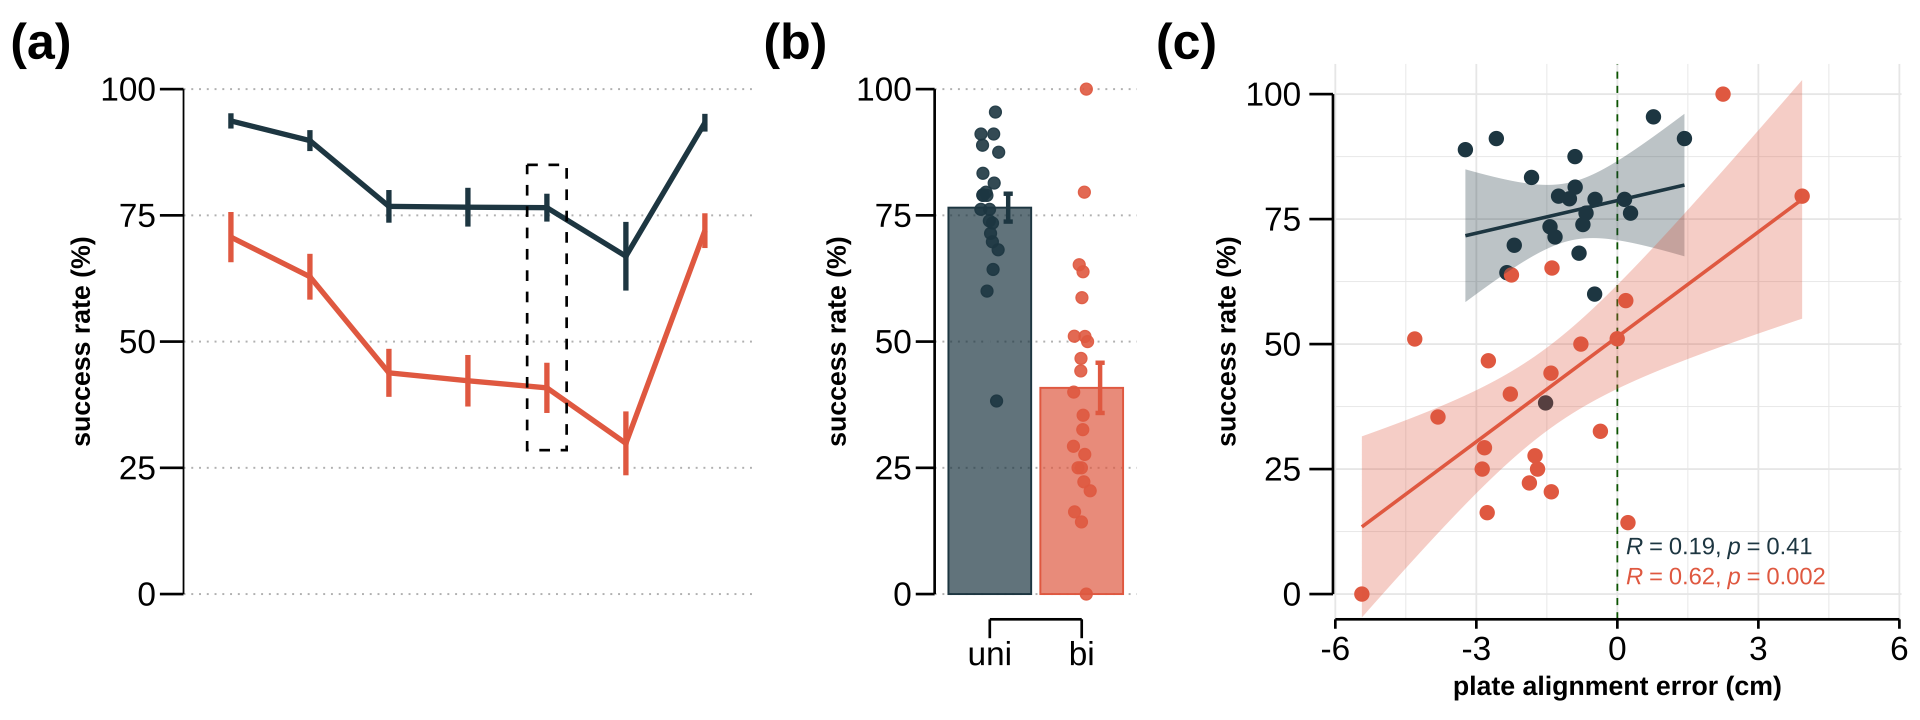

In [21]:
#----------------------------------Fig2-Layout------------------------------------
options(repr.plot.width=16, repr.plot.height=6)

Fig2 <- Fig2a + Fig2b + Fig2c + 
  plot_layout(ncol = 3, widths = c(2.25, 0.8, 2.25)) +
  plot_annotation(tag_levels = 'a', tag_prefix = '(', tag_suffix = ')') &
  theme(plot.tag = element_text(size = 30, face = "bold"))

Fig2
# ggsave(file="Fig2.svg", bg = "transparent", plot=Fig2, width=16, height=6)


### Figure 3
**Uni- and bimanual groups used different movement strategies to adapt to the perturbation.**

In [22]:
#----------------------------------Fig3-Plots------------------------------------

fct = 30
#--------------------------------------3a----------------------------------------

Fig3a = ggplot(aes(x = trial,y = Ry_raw*100, group=interaction(expGrp,cond), col=expGrp, fill = expGrp),
        data = dat3 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond!="washout" & gHand=="r-only")) +
             
    coord_capped_cart(ylim = c(28.5,50), xlim = c(1, 200), bottom = 'both', left = 'both') +
 
    geom_ribbon(aes(ymin = (fct*(gainF-(gainF*0.05*as.double(tgtHt)/3))),
                ymax = (fct*(gainF+(gainF*0.05*as.double(tgtHt)/3)))),
            col=NA,fill = "gray", alpha = .2) +
    geom_line(aes(y = fct*gainF),col="black", size =1.5) +

    stat_summary_bin(geom="ribbon", 
                 fun.data = mean_se, 
                 binwidth=1,lwd=NA,alpha=0.2,show.legend = FALSE) +
    stat_summary_bin(geom="line",fun.y = mean,
                 binwidth=1,lwd=1.5,alpha=1,show.legend = FALSE) +
    annotate("rect", xmin = 150, xmax = 201, ymin = 38, ymax = 48, fill = NA, 
            color = "black", linetype = "dashed", linewidth = 0.75) +
    scale_color_colorhex_d() + 
    scale_fill_colorhex_d() + 
    scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
    labs(y = "right hand displacement (cm)", x = "") +

    theme_clean() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0),"inches"),
      plot.background = element_blank(),
      panel.border = element_blank(),
      panel.spacing = unit(2, "lines"),
      axis.ticks.length=unit(0.2,"cm"),
      legend.position="top",
      axis.line.y = element_line(colour = "black"),
      axis.text.x = element_text(angle = 45, vjust = 0.8, hjust=0.8),
      strip.background = element_blank())

#--------------------------------------3b----------------------------------------

Fig3b = ggplot(aes(x = expGrp, y = Ry_raw_mn*100, col = expGrp, fill = expGrp),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="end.plateau" & gHand=="r-only")) +

    geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    coord_capped_cart(ylim = c(30,50),bottom = "both",left = "both") +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
    
    scale_x_discrete(labels = c("unimanual" = "uni", "bimanual" = "bi")) +
    scale_color_colorhex_d() +
    scale_fill_colorhex_d() +
    
    labs(x = "", y = "") +
    theme_pubclean() + thm
  

#--------------------------------------3c----------------------------------------

Fig3c_pre = ggplot(aes( x = Ry_raw_mn*100, y = final_plateAlign_raw_mn, col = expGrp, fill = expGrp),
            data = summDat2 %>% filter(grp=="adults", tgtHtC=="narrow", cond3=="end.plateau" & gHand=="r-only")) + 

    coord_capped_cart(xlim = c(35, 50), ylim = c(-6, 6),left = "both",bottom = "both",expand = 1) + 
    geom_hline(yintercept = 0, col = "darkgreen", lty="dashed") +  
    geom_vline(xintercept = 46.14, col = "darkgreen", lty="dashed") + 
    
    geom_point(show.legend = FALSE, size = 3, stroke = 1) + 
    geom_smooth(alpha = 0.2, formula = y~x, method = "lm",show.legend = FALSE) +
    stat_cor(aes(group = expGrp), method = "pearson", show.legend = FALSE) +

    scale_color_colorhex_d() +
    scale_fill_colorhex_d() +
    labs(x = "right hand displacement (cm)", y = "plate alignment error (cm)") +
    theme_minimal() + thm + 
    theme(plot.background = element_blank(),
        panel.border = element_blank(),
        axis.ticks.length=unit(0.2,"cm"),
        legend.position="top",
        axis.text.x = element_text(size = 30),
        axis.text.y = element_text(size = 30),
        axis.ticks.length.y=unit(0.5,units = "cm"),
        axis.line.y = element_line(colour = "black")
       )
Fig3c = ggMarginal(Fig3c_pre, groupColour = TRUE, groupFill = TRUE, type = "density",adjust = 1)

#--------------------------------------3d----------------------------------------
# placeholder for gameplay image of tilt
Fig3d = ggplot() + 
    annotate("text", x = 0.3, y = 0.4, label = "Placeholder for\ngameplay image of tilt", size = 6, hjust = 0.5, vjust = 0.5) +
    theme_void() + theme(plot.background = element_rect(fill = "white", color = "black"))
#--------------------------------------3e----------------------------------------

Fig3e = ggplot(aes(x = trial,y = tilt_compR_raw*100, group=interaction(expGrp,cond), col=expGrp, fill = expGrp),
        data = dat3 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond!="washout" & gHand=="r-only" & tilt_compR_raw<0.2)) +
             
    coord_capped_cart(ylim = c(-5,5), xlim = c(1, 200), bottom = 'both', left = 'both') +
 
    geom_line(aes(y = 0),col="black", size =1.5) +

    stat_summary_bin(geom="ribbon", fun.data = mean_se, binwidth=1,lwd=NA,alpha=0.2,show.legend = FALSE) +
    stat_summary_bin(geom="line",fun.y = mean, binwidth=1,lwd=1.5,alpha=1,show.legend = FALSE) +
    
    annotate("rect", xmin = 150, xmax = 201, ymin = -1, ymax = 4, fill = NA, 
            color = "black", linetype = "dashed", linewidth = 0.75) +

    scale_color_colorhex_d() + 
    scale_fill_colorhex_d() + 
    scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
    labs(y = "right hand compensation (cm)", x = "") +

    theme_pubclean() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0),"inches"),
      plot.background = element_blank(),
      panel.border = element_blank(),
      panel.spacing = unit(2, "lines"),
      axis.ticks.length=unit(0.2,"cm"),
      legend.position="top",
      axis.line.y = element_line(colour = "black"),
      axis.text.x = element_text(angle = 45, vjust = 0.8, hjust=0.8),
      strip.background = element_blank())

#--------------------------------------3f----------------------------------------

Fig3f = ggplot(aes(x = expGrp, y = tilt_compR_raw_mn*100, col = expGrp, fill = expGrp),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="end.plateau" & gHand=="r-only")) +

    geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    coord_capped_cart(ylim = c(-5,5),bottom = "both",left = "both") +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
    
    scale_x_discrete(labels = c("unimanual" = "uni", "bimanual" = "bi")) +
    scale_color_colorhex_d() +
    scale_fill_colorhex_d() +
    
    labs(x = "", y = "") +
    theme_pubclean() + thm



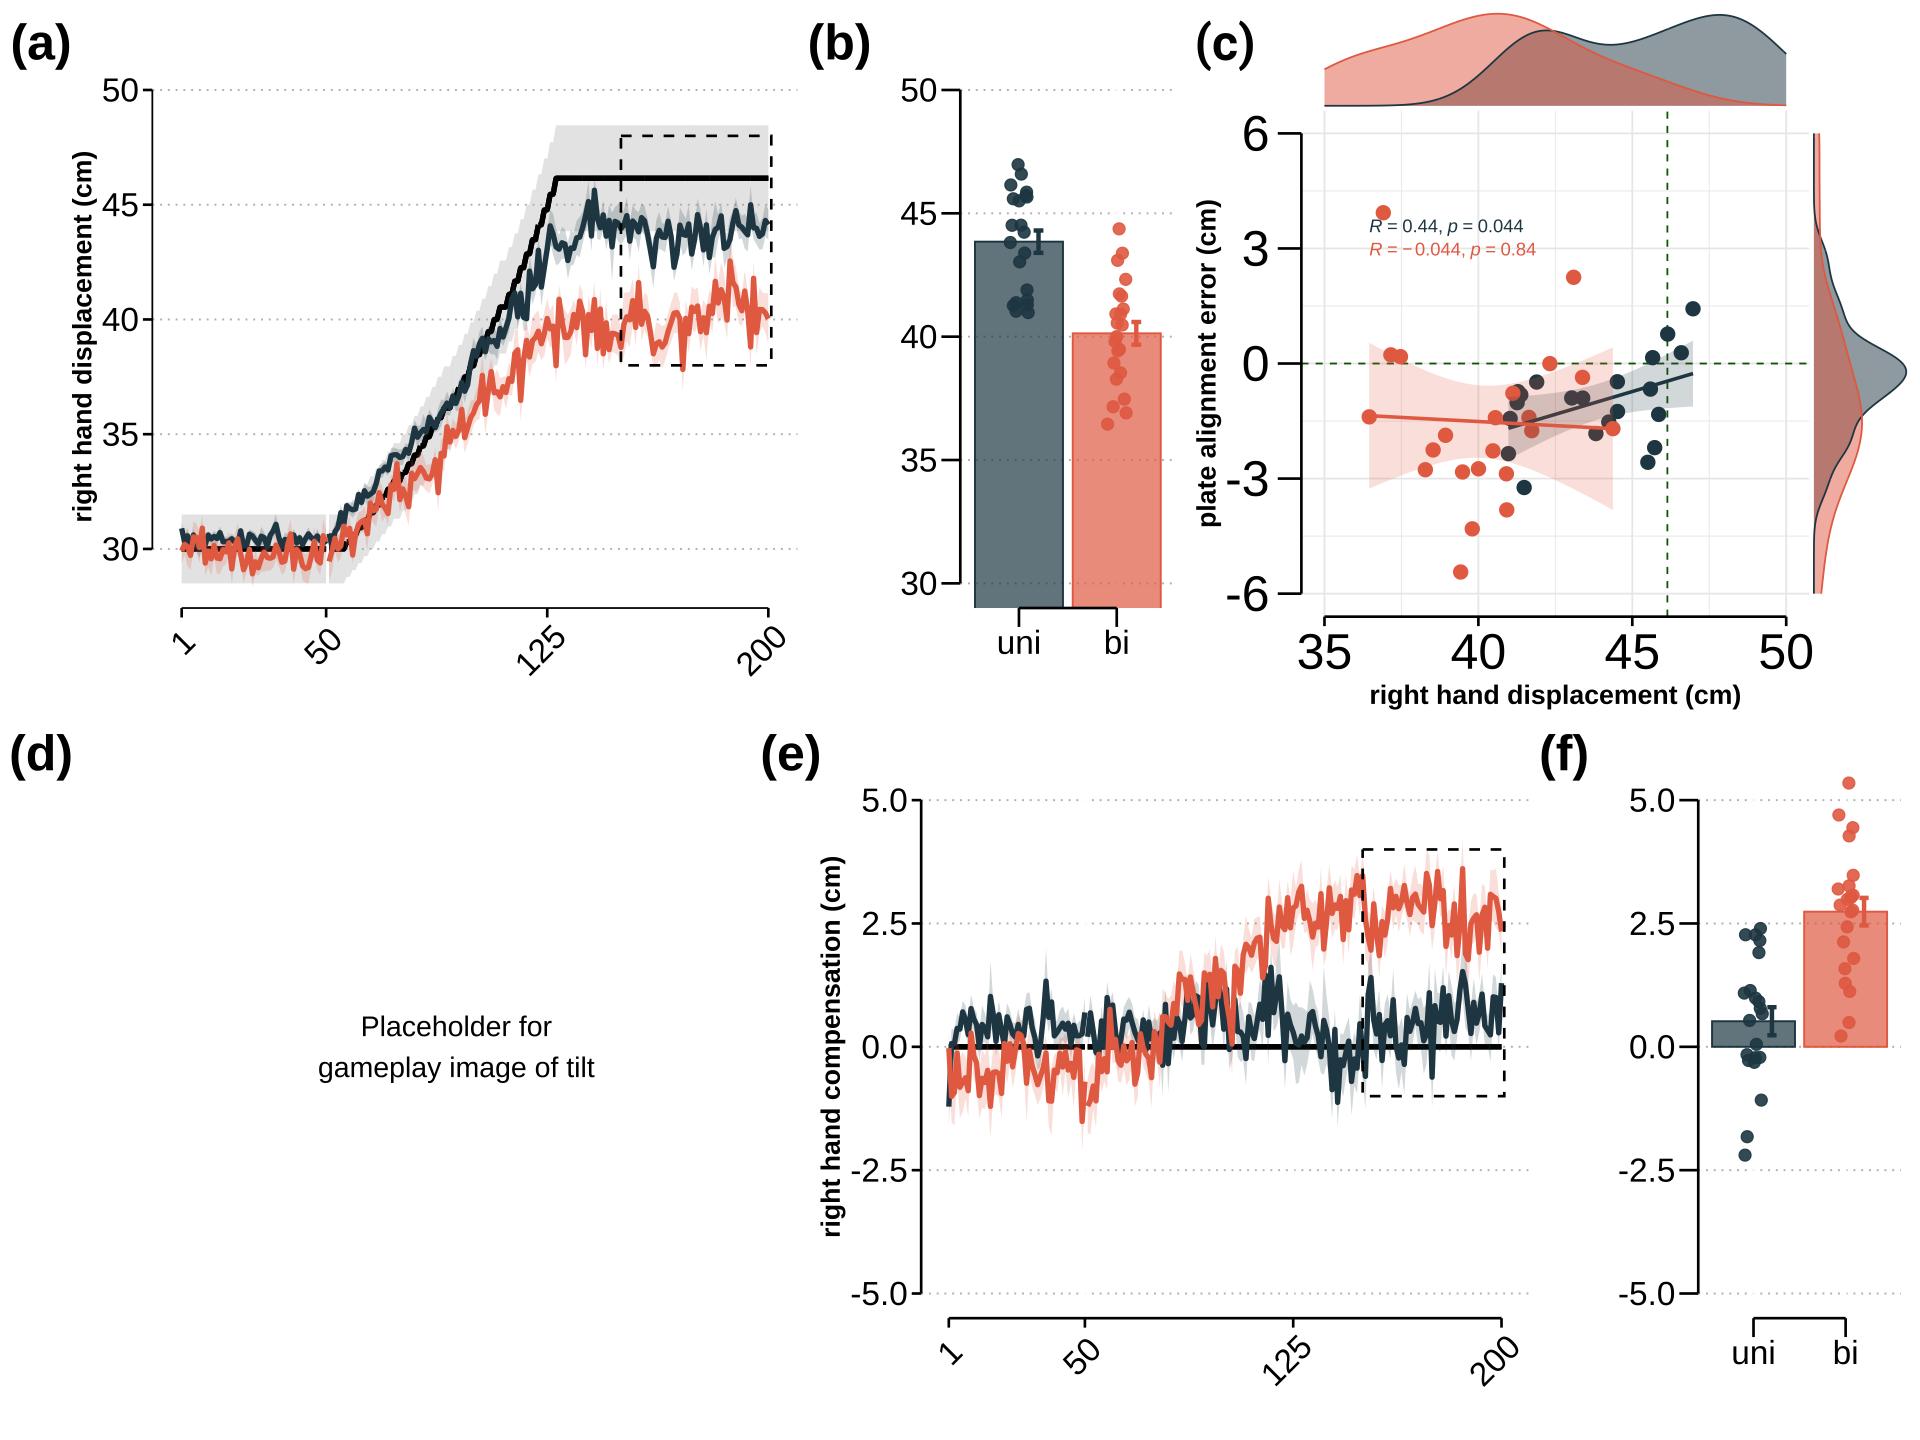

In [23]:
#----------------------------------Fig3-Layout------------------------------------
options(repr.plot.width=16, repr.plot.height=12)

top_row <- Fig3a | Fig3b | Fig3c
  top_row <- top_row + plot_layout(widths = c(3, 1, 3))

bottom_row <- Fig3d | Fig3e | Fig3f
  bottom_row <- bottom_row + plot_layout(widths = c(3, 3, 1))

Fig3 <- top_row / bottom_row +
  plot_annotation(tag_levels = 'a', tag_prefix = '(', tag_suffix = ')') &
  theme(plot.tag = element_text(size = 30, face = "bold"))

Fig3

# ggsave(file="Fig3.svg", bg = "transparent", plot=Fig3, width=16, height=12)


### Figure 4
**Unimanual group shows larger aftereffects in displacement than bimanual group.**

In [24]:
#----------------------------------Fig4-Plots------------------------------------
#--------------------------------------4a----------------------------------------

Fig4a = ggplot(aes(x = trial,y = (Ry_raw)*100, group=expGrp, col = expGrp, fill = expGrp),
             data = dat3 %>% filter(grp=="adults" & tgtHtC=="narrow", cond=="washout", gHand=="r-only")) +
    
    coord_capped_cart(ylim = c(28,40), xlim = c(201, 260), bottom = 'both', left = 'both') +
    stat_summary_bin(geom="ribbon", fun.data = mean_se, binwidth=1,lwd=NA,alpha=0.5,show.legend = FALSE) +
    stat_summary_bin(geom="line",fun.y = mean,binwidth=1,lwd=1.5,alpha=0.9,show.legend = FALSE) +

    geom_vline(xintercept = c(211,241),lty = "dashed", col = "gray") +
    
    scale_x_continuous(breaks = c(1,50,125,200, 260), labels = c("1","50","125","200","260")) +
    scale_color_colorhex_d() + 
    scale_fill_colorhex_d() + 

    annotate("rect", xmin = 200, xmax = 206, ymin = 28, ymax = 37, fill = NA, 
            color = "#404040e3", linetype = "dashed", linewidth = 0.75) +

    labs(x = "", y = "right hand displacement (cm)") +
    theme_clean() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0),"inches"),
      plot.background = element_blank(),
      panel.border = element_blank(),
      panel.spacing = unit(2, "lines"),
      axis.ticks.length=unit(0.2,"cm"),
      axis.text.x = element_text(angle = 45, hjust = 1),
      legend.position="top",
      axis.line.y = element_line(colour = "black"))

#-----------------------------------4a-inset-------------------------------------

Fig4a_inset = ggplot(aes(x = expGrp, y = Ry_raw_mn*100, col = expGrp, fill = expGrp),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="start.washout" & gHand=="r-only")) +

    geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    coord_capped_cart(ylim = c(25,40),bottom = "both",left = "both") +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
    
    scale_x_discrete(labels = c("unimanual" = "uni", "bimanual" = "bi")) +
    scale_color_colorhex_d() +
    scale_fill_colorhex_d() +
    
    labs(x = "", y = "") + # right hand displacement (cm) removed label
    theme_pubclean() + thm

#--------------------------------------4b----------------------------------------

Fig4b = ggplot(aes(x = trial,y = (Py_raw)*100, group=expGrp, col = expGrp, fill = expGrp),
             data = dat3 %>% filter(grp=="adults", tgtHtC=="narrow", cond=="washout", gHand=="r-only")) +
    coord_capped_cart(ylim = c(28,40), xlim = c(201, 260), bottom = 'both', left = 'both') +
    stat_summary_bin(geom="ribbon", fun.data = mean_se, binwidth=1,lwd=NA,alpha=0.5,show.legend = FALSE) +
    stat_summary_bin(geom="line",fun.y = mean,binwidth=1,lwd=1.5,alpha=0.9,show.legend = FALSE) +
    
    geom_vline(xintercept = c(211,241),lty = "dashed", col = "gray") +

    scale_x_continuous(breaks = c(1,50,125,200, 260), labels = c("1","50","125","200","260")) +
    scale_color_colorhex_d() + 
    scale_fill_colorhex_d() + 
    annotate("rect", xmin = 200, xmax = 206, ymin = 28, ymax = 37, fill = NA, 
           color = "#404040e3", linetype = "dashed", linewidth = 0.75) +

    labs(x = "", y = "plate displacement (cm)") +
    theme_clean() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0),"inches"),
      plot.background = element_blank(),
      panel.border = element_blank(),
      panel.spacing = unit(2, "lines"),
      axis.ticks.length=unit(0.2,"cm"),
      legend.position="top",
      axis.line.y = element_line(colour = "black"),
      axis.text.x = element_text(angle = 45, vjust = 0.8, hjust=0.8),
      strip.background = element_blank())

#-----------------------------------4b-inset-------------------------------------

Fig4b_inset = ggplot(aes(x = expGrp, y = Py_raw_mn*100, col = expGrp, fill = expGrp),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="start.washout" & gHand=="r-only")) +

    geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    coord_capped_cart(ylim = c(25,40),bottom = "both",left = "both") +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
    
    scale_x_discrete(labels = c("unimanual" = "uni", "bimanual" = "bi")) +
    scale_color_colorhex_d() +
    scale_fill_colorhex_d() +
    
    labs(x = "", y = "") + # plate displacement (cm) removed label
    theme_pubclean() + thm 
#--------------------------------------4b----------------------------------------

Fig4c = ggplot(summDat2_wide %>% filter(grp=="adults" & tgtHtC=="narrow" & gHand=="r-only"),
       aes(y = Ry_raw_mn_start.washout*100, x = Ry_raw_mn_end.plateau*100, col = expGrp, fill = expGrp)) + 
  coord_capped_cart(ylim = c(25, 40), xlim = c(35, 50), left = "both", bottom="both") + 

  geom_point(show.legend = FALSE, size = 4, alpha = 0.9) + 
  geom_smooth(formula = y~x, alpha = 0.2, method = "lm",show.legend = FALSE) +

  stat_cor(size = 6, label.x.npc= 0.6, label.y = c(38,39), method = "pearson", show.legend = FALSE) +

  scale_color_colorhex_d() +
  scale_fill_colorhex_d() +
  
  labs(x = "right hand displacement (cm)\nat the end of adaptation", y = "right hand displacement (cm)\nat the start of washout") +
  theme_minimal() + thm 

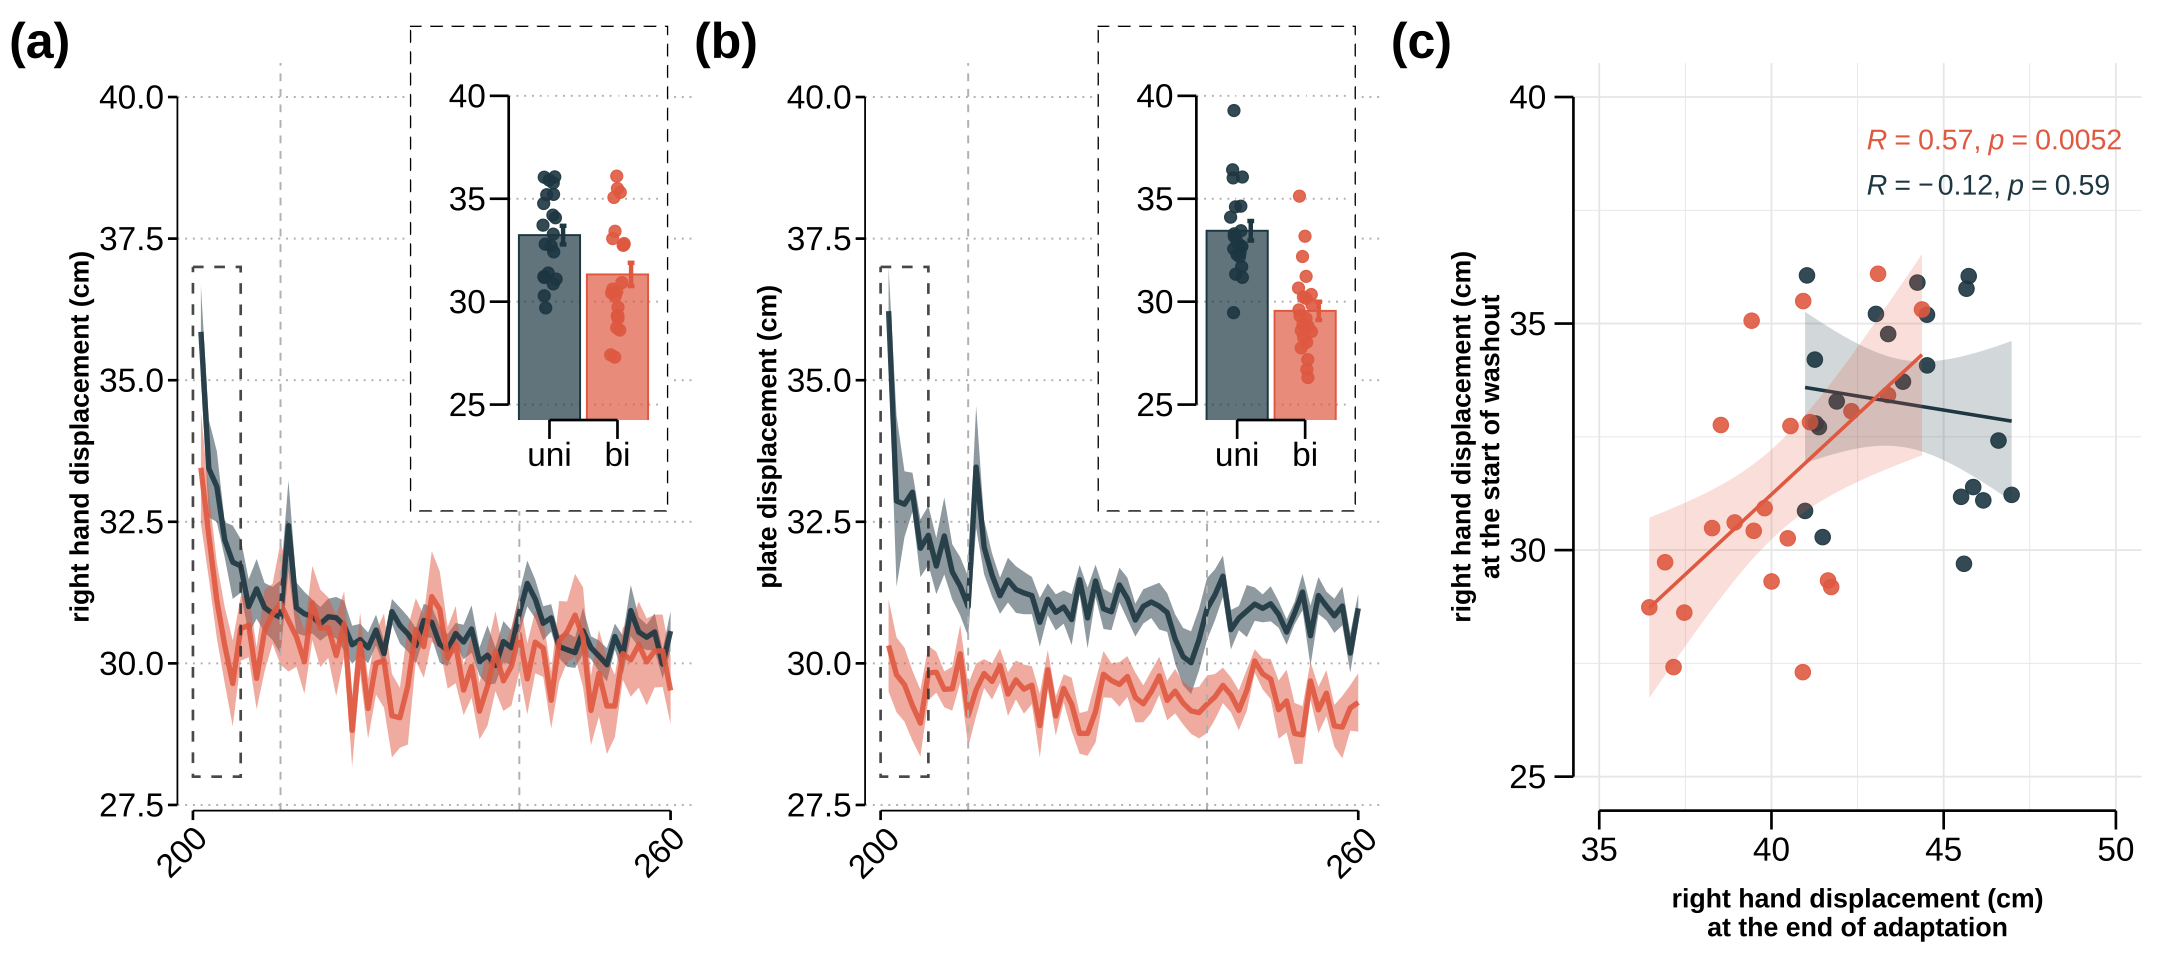

In [25]:
#----------------------------------Fig4-Layout------------------------------------

options(repr.plot.width=18, repr.plot.height=8)

Fig4a_with_inset <- Fig4a + 
  inset_element(Fig4a_inset, left = 0.45, bottom = 0.4, right = 0.95, top = 1.05)+
   theme(plot.background = element_rect(fill = "white", color = "black", linetype = "dashed", size = 0.75))

Fig4b_with_inset <- Fig4b + 
  inset_element(Fig4b_inset, left = 0.45, bottom = 0.4, right = 0.95, top = 1.05)+
   theme(plot.background = element_rect(fill = "white", color = "black", linetype = "dashed", size = 0.75))

Fig4 <- Fig4a_with_inset | Fig4b_with_inset | Fig4c

Fig4 <- Fig4 + 
  plot_layout(widths = c(1, 1, 1.1)) +
  plot_annotation(tag_levels = list(c('(a)', '','(b)','','(c)'))) &
  theme(plot.tag = element_text(size = 30, face = "bold"))

Fig4

# ggsave(file="Fig4.svg", bg = "transparent", plot=Fig4, width=18, height=8)


### Figure 5
**Bimanual group uses more feedback control than unimanual group.**

In [26]:
#----------------------------------Fig5-Plots------------------------------------
# scaling plot preferences    
    bb = 2
    fct = 1
    pd = c(20, 100)

    # define colors for use in all plots
    uni_color <- "#264653"          # original blue-green
    uni_color_light <- "#458999"    # lighter blue-green
    bi_color <- "#e76f51"           # original coral-red
    bi_color_light <- "#fbad93ff"   # lighter coral-red

#--------------------------------------5a----------------------------------------

Fig5a = ggplot(aes(x = expGrp, y = peakspeedR_raw_mn, col = expGrp, fill = expGrp),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="end.plateau" & gHand=="r-only")) +

    geom_point(position = position_jitterdodge(jitter.width = 0.35, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    coord_capped_cart(ylim = c(0.25,1.25),bottom = "both",left = "both") +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
    
    scale_x_discrete(labels = c("unimanual" = "uni", "bimanual" = "bi")) +
    scale_color_colorhex_d() +
    scale_fill_colorhex_d() +
    
    labs(x = "", y = "peak speed (m/s)") +
    theme_pubclean() + thm + 
    theme(plot.margin = unit(c(0, 0, 0, 0), "cm"),
        plot.background = element_blank())

#--------------------------------------5b----------------------------------------

Fig5b = ggplot() + 
    annotate("text", x = 0.5, y = 0.5, label = "Placeholder for\nvelocity profiles", size = 6, hjust = 0.5, vjust = 0.5) +
    theme_void() + theme(plot.background = element_rect(fill = "white", color = "black"))

#--------------------------------------5c----------------------------------------

Fig5c = ggplot(aes(x = trial, y = speed, group = cond, col = interaction(as.factor(percDist), expGrp), 
                   fill = interaction(as.factor(percDist), expGrp)),
            data = elong0 %>% filter(grp=="adults" & gHand=="r-only" & percDist %in% pd & tgtHt=="3" & hand=="right")) +
  
  coord_capped_cart(ylim = c(0.75, 1.75), xlim = c(1, 260), bottom = 'both', left = 'both') +
  geom_hline(yintercept = 1, col = "darkgray") +
  
  stat_summary_bin(aes(fill = interaction(as.factor(percDist), expGrp), 
                       group = interaction(as.factor(percDist), cond, expGrp)), 
                   geom = "ribbon", fun.data = mean_se_, binwidth = bb, 
                   lwd = NA, alpha = 0.2, show.legend = FALSE) +
  
  stat_summary_bin(aes(col = interaction(as.factor(percDist), expGrp), 
                       group = interaction(as.factor(percDist), cond, expGrp)), 
                   geom = "line", fun.data = mean_se_, binwidth = bb, 
                   lwd = 2, alpha = 0.9, show.legend = TRUE) +
  
  scale_x_continuous(breaks = c(1, 50, 125, 200, 260), labels = c("1","50", "125", "200", "260")) +
    
  scale_color_manual(values = c("20.unimanual" = uni_color_light, "100.unimanual" = uni_color,
                                "20.bimanual" = bi_color_light, "100.bimanual" = bi_color),
                     labels = c("early", "overall", "early", "overall"), 
                     name = "") +
  scale_fill_manual(values = c("20.unimanual" = uni_color_light, "100.unimanual" = uni_color,
                               "20.bimanual" = bi_color_light, "100.bimanual" = bi_color),
                    labels = c("early", "overall", "early", "overall"), 
                    name = "", guide = "none") +
  
  labs(x = "", y = "speed scaling\n(baseline–normalized units)") +
  
  facet_wrap(~expGrp) +
  theme_pubclean() + thm +
  theme(plot.margin = unit(c(0, 0, 0, 0), "inches"),
        plot.background = element_blank(),
        panel.border = element_blank(),
        panel.spacing = unit(2, "lines"),
        axis.ticks.length = unit(0.2, "cm"),
        axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = c(0.5, 0.85),
        legend.direction = "horizontal",
        legend.box.background = element_rect(color = "black", size = 1),
        strip.background = element_blank(),
        axis.line.y = element_line(colour = "black"))

#--------------------------------------5d----------------------------------------

Fig5d = ggplot(aes(x = expGrp, y = onCompR_corr_mn, col = expGrp, fill = expGrp),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="end.plateau" & gHand=="r-only")) +

    geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    coord_capped_cart(ylim = c(-0.51,0.51),bottom = "both",left = "both") +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
    
    scale_x_discrete(labels = c("unimanual" = "uni", "bimanual" = "bi")) +
    scale_color_colorhex_d() +
    scale_fill_colorhex_d() +
    
    labs(x = "", y = "scaling change\n(overall – early)") +

    theme_pubclean() + thm + 
    theme(plot.margin = unit(c(0, 0, 0, 0), "inches"),
        plot.background = element_blank())

#--------------------------------------5e----------------------------------------

Fig5e = ggplot(aes(y = slopesR2_corr_mn_start.washout, x = onCompR_corr_mn_end.plateau, col = expGrp, fill = expGrp),
        data = summDat2_wide %>% filter(grp=="adults" & tgtHtC=="narrow" & gHand=="r-only")) + 

    coord_capped_cart(ylim = c(0.25, 2), xlim = c(-0.5, 0.5)) + 
    
    geom_point(show.legend = FALSE, size = 3, alpha = 0.9, stroke=1) + 
    geom_smooth(aes(group = 1), formula = y~x, col = "black", lty = "dashed", alpha = 0.2, method = "lm",show.legend = FALSE) +
    
    geom_hline(yintercept = 1, color = "black", size = 0.5) +
    geom_vline(xintercept = 0, color = "black", size = 0.5) +
    
    stat_cor(aes(group = 1), size = 6, label.x.npc = 0.53, label.y = 1.9, method = "pearson", nboot = 1000, show.legend = FALSE) +

    scale_color_colorhex_d() +
    scale_fill_colorhex_d() +
    
    labs(x = "scaling change\nat the end of adaptation", y = "aftereffects in\nearly speed scaling ") +
    theme_minimal() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0), "inches"),
          plot.background = element_blank(),
          axis.line = element_blank(), panel.border = element_blank())
    
        

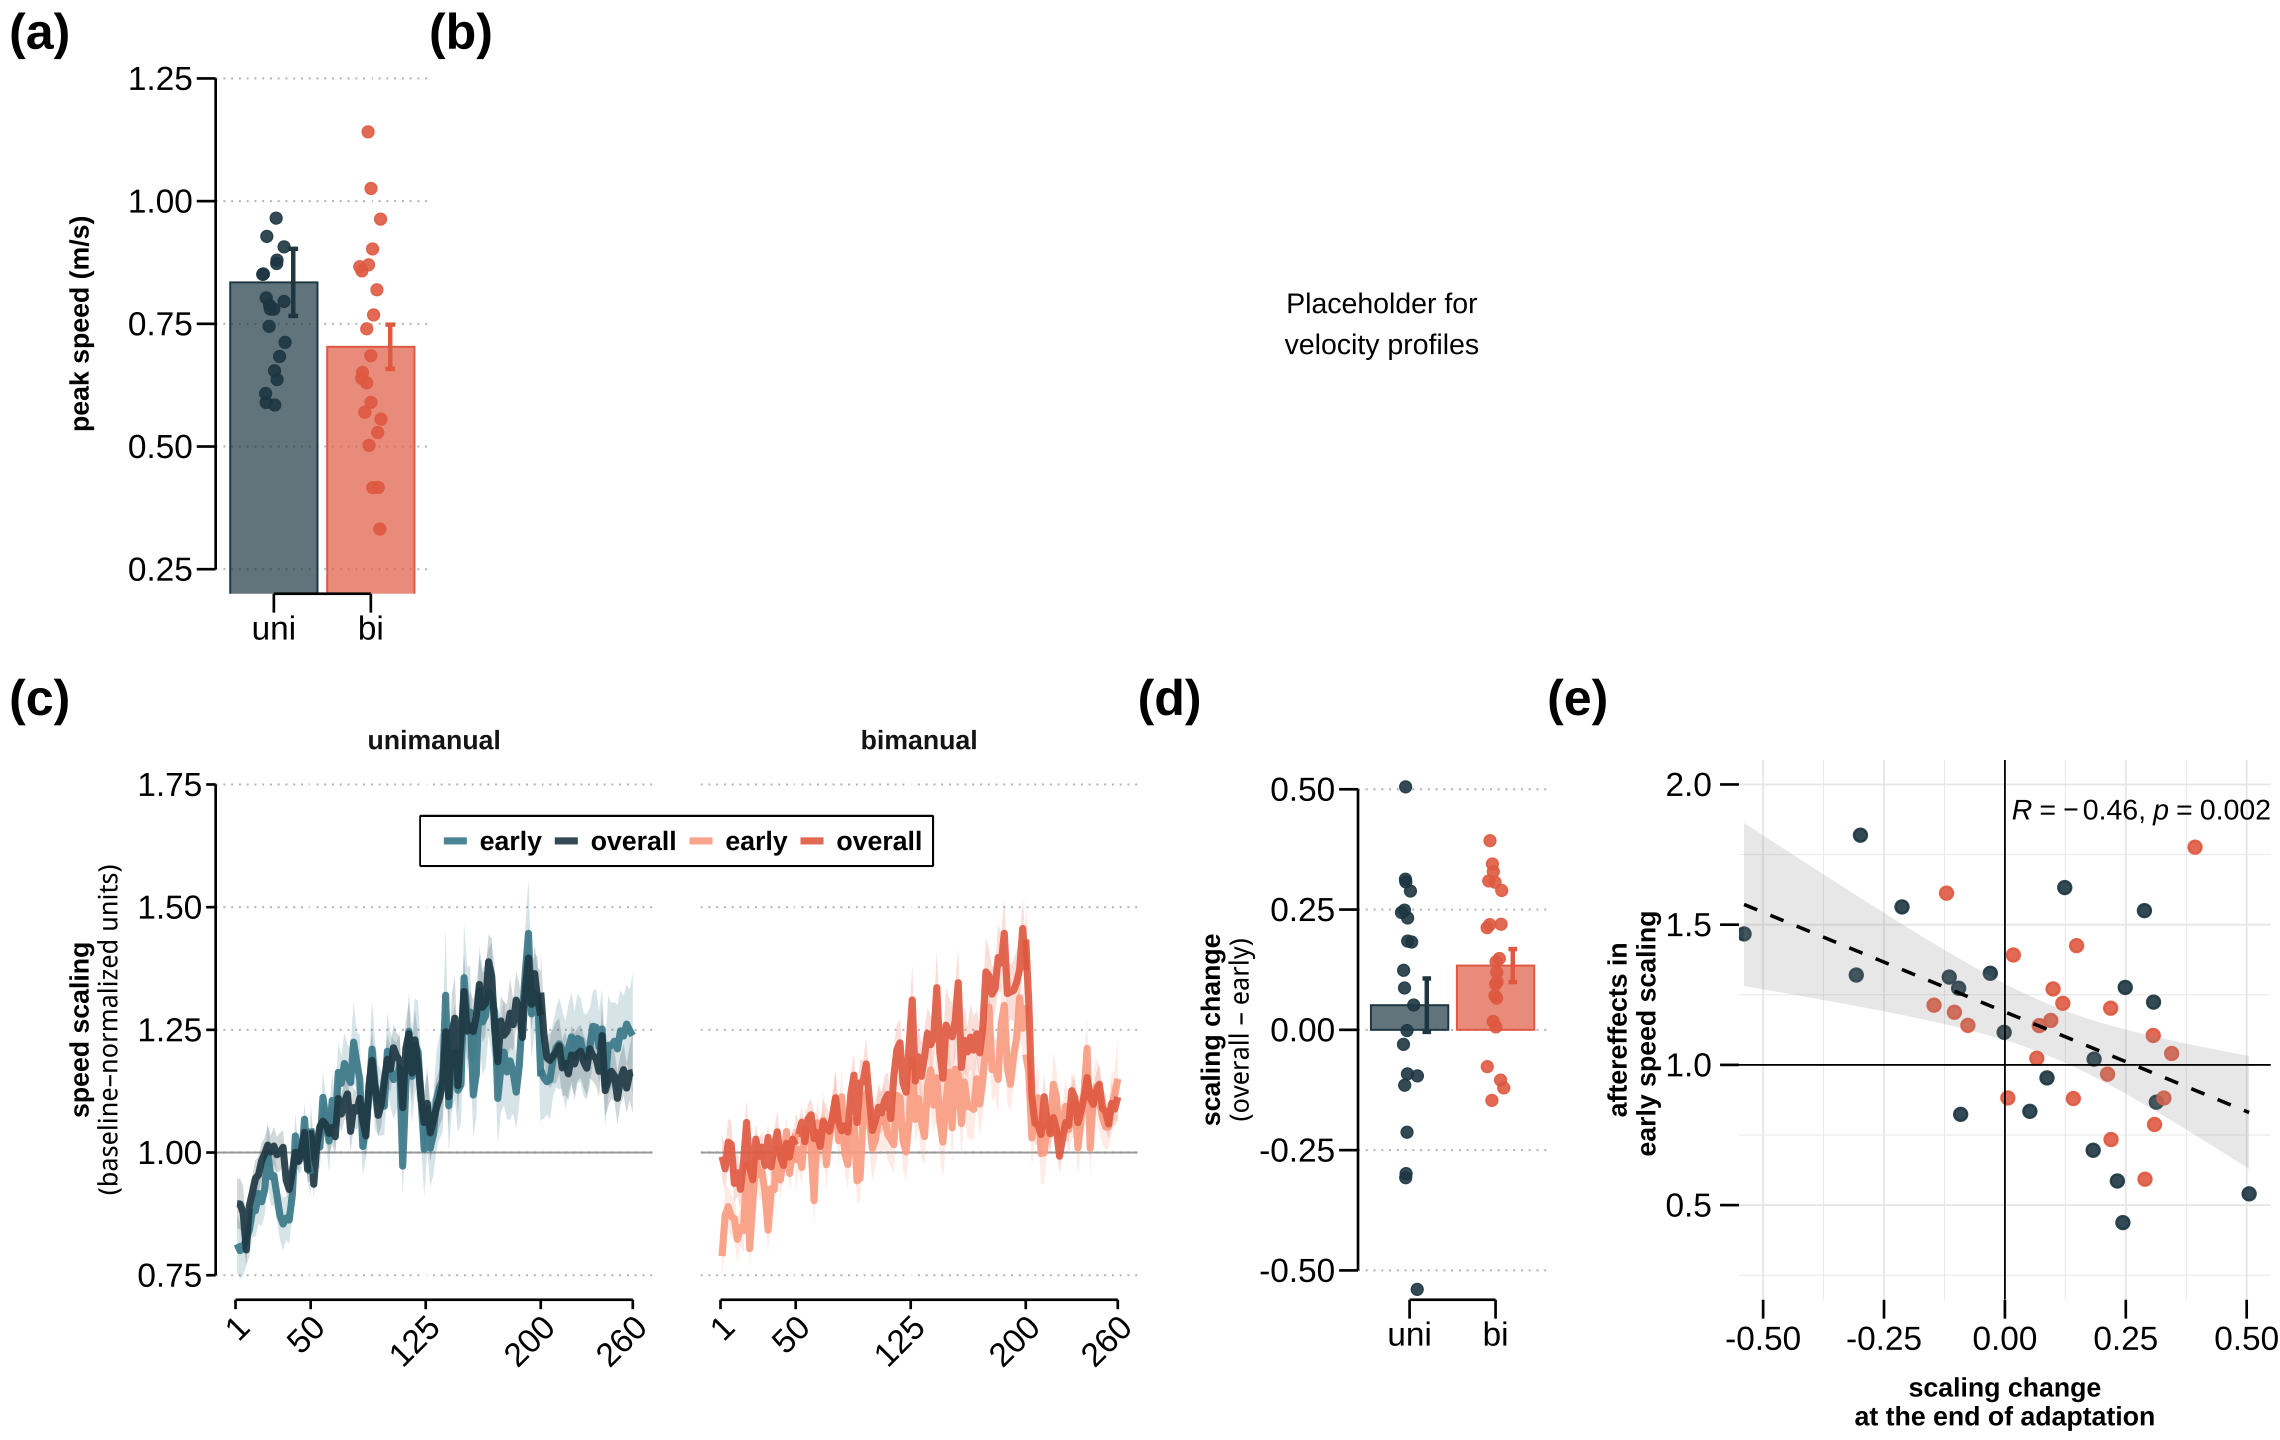

In [27]:
#----------------------------------Fig5-Layout------------------------------------
options(repr.plot.width=19, repr.plot.height=12)

top_row <- Fig5a | Fig5b
  top_row <- top_row + plot_layout(widths = c(0.75, 6.25))  # a=1, b=6 (spans c+d+e space)

bottom_row <- Fig5c | Fig5d | Fig5e  
  bottom_row <- bottom_row + plot_layout(widths = c(3.9, 0.8, 2.25))  # c=4, d=1, e=2 (total=7)

Fig5 <- top_row / bottom_row +
  plot_layout(heights = c(1, 1)) +
  plot_annotation(tag_levels = 'a', tag_prefix = '(', tag_suffix = ')') &
  theme(plot.tag = element_text(size = 30, face = "bold"))

Fig5

# ggsave(file="Fig5.svg", bg = "transparent", plot=Fig5, width=19, height=12)


### Figure 6
**Wide target improved bimanual success and reduced feedback reliance, but hand compensations persisted.**

In [28]:
#----------------------------------Fig6-Plots------------------------------------
# preferences for order and color
  #relevel so that appears in the same order as previous plots + wide
  summDat2$OmniGrp <- factor(summDat2$OmniGrp,levels = c("uni-narrow", "bi-narrow", "bi-wide"))
  # color preferences
  uni_color <- "#264653" 
  bi_color <- "#e76f51" 

#--------------------------------------6a----------------------------------------

Fig6a = ggplot(aes(x = OmniGrp, y = succRate, group = OmniGrp, col = OmniGrp, fill = OmniGrp),
        data = summDat2 %>% filter(grp=="adults" & gHand=="r-only" & cond3=="end.plateau")) +
    coord_capped_cart(ylim = c(0,100),bottom = "both",left = "both") +
    
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), stroke = 1.5, 
                 size = 1.2, show.legend = FALSE, alpha = 0.8) +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, 
                 linewidth = 1.25, show.legend = FALSE) +
    geom_point(position = position_jitterdodge(jitter.width = 0.1, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    
    scale_color_manual(values = c("uni-narrow" = uni_color, "bi-narrow" = bi_color,"bi-wide" = bi_color)) +
    scale_fill_manual(values = c("uni-narrow" = uni_color, "bi-narrow" = bi_color,"bi-wide" = "white")) +
  
    labs(x = "", y = "success rate (%)") +
    
    theme_pubclean() + thm  + 
    theme(axis.text.x = element_text(angle = 30, vjust = 0.75, hjust = 0.75))

#--------------------------------------6b----------------------------------------

Fig6b = ggplot() + 
    annotate("text", x = 0.3, y = 0.4, label = "Placeholder for\nwide target velocity profile", size = 6, hjust = 0.5, vjust = 0.5) +
    theme_void() + theme(plot.background = element_rect(fill = "white", color = "black"))

#--------------------------------------6c----------------------------------------
Fig6c = ggplot(aes(x = OmniGrp, y = onCompR_corr_mn, group = OmniGrp, col = OmniGrp, fill = OmniGrp),
        data = summDat2 %>% filter(grp=="adults" & gHand=="r-only" & cond3=="end.plateau")) +
    coord_capped_cart(ylim = c(-0.5,0.5),bottom = "both",left = "both") +
    
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), stroke = 1.5, 
                 size = 1.2, show.legend = FALSE, alpha = 0.8) +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, 
                 linewidth = 1.25, show.legend = FALSE) +
    geom_point(position = position_jitterdodge(jitter.width = 0.1, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    
    scale_color_manual(values = c("uni-narrow" = uni_color, "bi-narrow" = bi_color,"bi-wide" = bi_color)) +
    scale_fill_manual(values = c("uni-narrow" = uni_color, "bi-narrow" = bi_color,"bi-wide" = "white")) +
  
    labs(x = "", y = "scaling change\n(overall — early)") +
    
    theme_pubclean() + thm  + 
    theme(axis.text.x = element_text(angle = 30, vjust = 0.75, hjust = 0.75))

#--------------------------------------6d----------------------------------------

Fig6d = ggplot(aes(x = trial,y = tilt_compR_raw*100, group=cond),
        data = dat3 %>% filter(grp=="adults" & tgtHtC=="wide" & cond!="washout" & gHand=="r-only")) +
             
    coord_capped_cart(ylim = c(-5.5,5.5), xlim = c(1, 200), bottom = 'both', left = 'both') +
 
    geom_line(aes(y = 0),col="black", size =1.5) +

    stat_summary_bin(geom="ribbon",fill=bi_color, fun.data = mean_se, binwidth=1,lwd=NA,alpha=0.2,show.legend = FALSE) +
    stat_summary_bin(geom="line",col=bi_color,fun.y = mean, binwidth=1,lwd=1.5,linetype="dashed", alpha=1,show.legend = FALSE) +
    
    annotate("rect", xmin = 150, xmax = 201, ymin = 1.25, ymax = 5, fill = NA, 
            color = "black", linetype = "dashed", linewidth = 0.75) +

    scale_color_colorhex_d() + 
    scale_fill_colorhex_d() + 
    scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
    labs(y = "right hand compensation (cm)", x = "") +

    theme_clean() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0),"inches"),
      plot.background = element_blank(),
      panel.border = element_blank(),
      panel.spacing = unit(2, "lines"),
      axis.ticks.length=unit(0.2,"cm"),
      legend.position="top",
      axis.line.y = element_line(colour = "black"),
      axis.text.x = element_text(angle = 45, vjust = 0.8, hjust=0.8),
      strip.background = element_blank())

#-------------------------------------6d-inset-------------------------------------

Fig6d_inset = ggplot(aes(x = OmniGrp, y = tilt_compR_raw_mn*100, col = OmniGrp, fill = OmniGrp),
              data = summDat2 %>% filter(grp=="adults" & cond3=="end.plateau" & gHand=="r-only")) +

        coord_capped_cart(ylim = c(-3.9,6),bottom = "both",left = "both") +

        stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
        stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
        geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), alpha = 0.9, size = 2, show.legend =FALSE) +
    
        scale_x_discrete(labels = c("unimanual" = "uni", "bimanual" = "bi")) +
        scale_color_manual(values = c("uni-narrow" = uni_color, "bi-narrow" = bi_color,"bi-wide" = bi_color)) +
        scale_fill_manual(values = c("uni-narrow" = uni_color, "bi-narrow" = bi_color,"bi-wide" = "white")) +
    
        labs(x = "", y = "") + # compensation at hand (cm) - removed inset label
        theme_pubclean() + thm +
        theme(plot.margin = unit(c(0, 0, 0, 0),"inches"),
              axis.text.x = element_text(angle = 30, vjust = 0.75, hjust = 0.75))


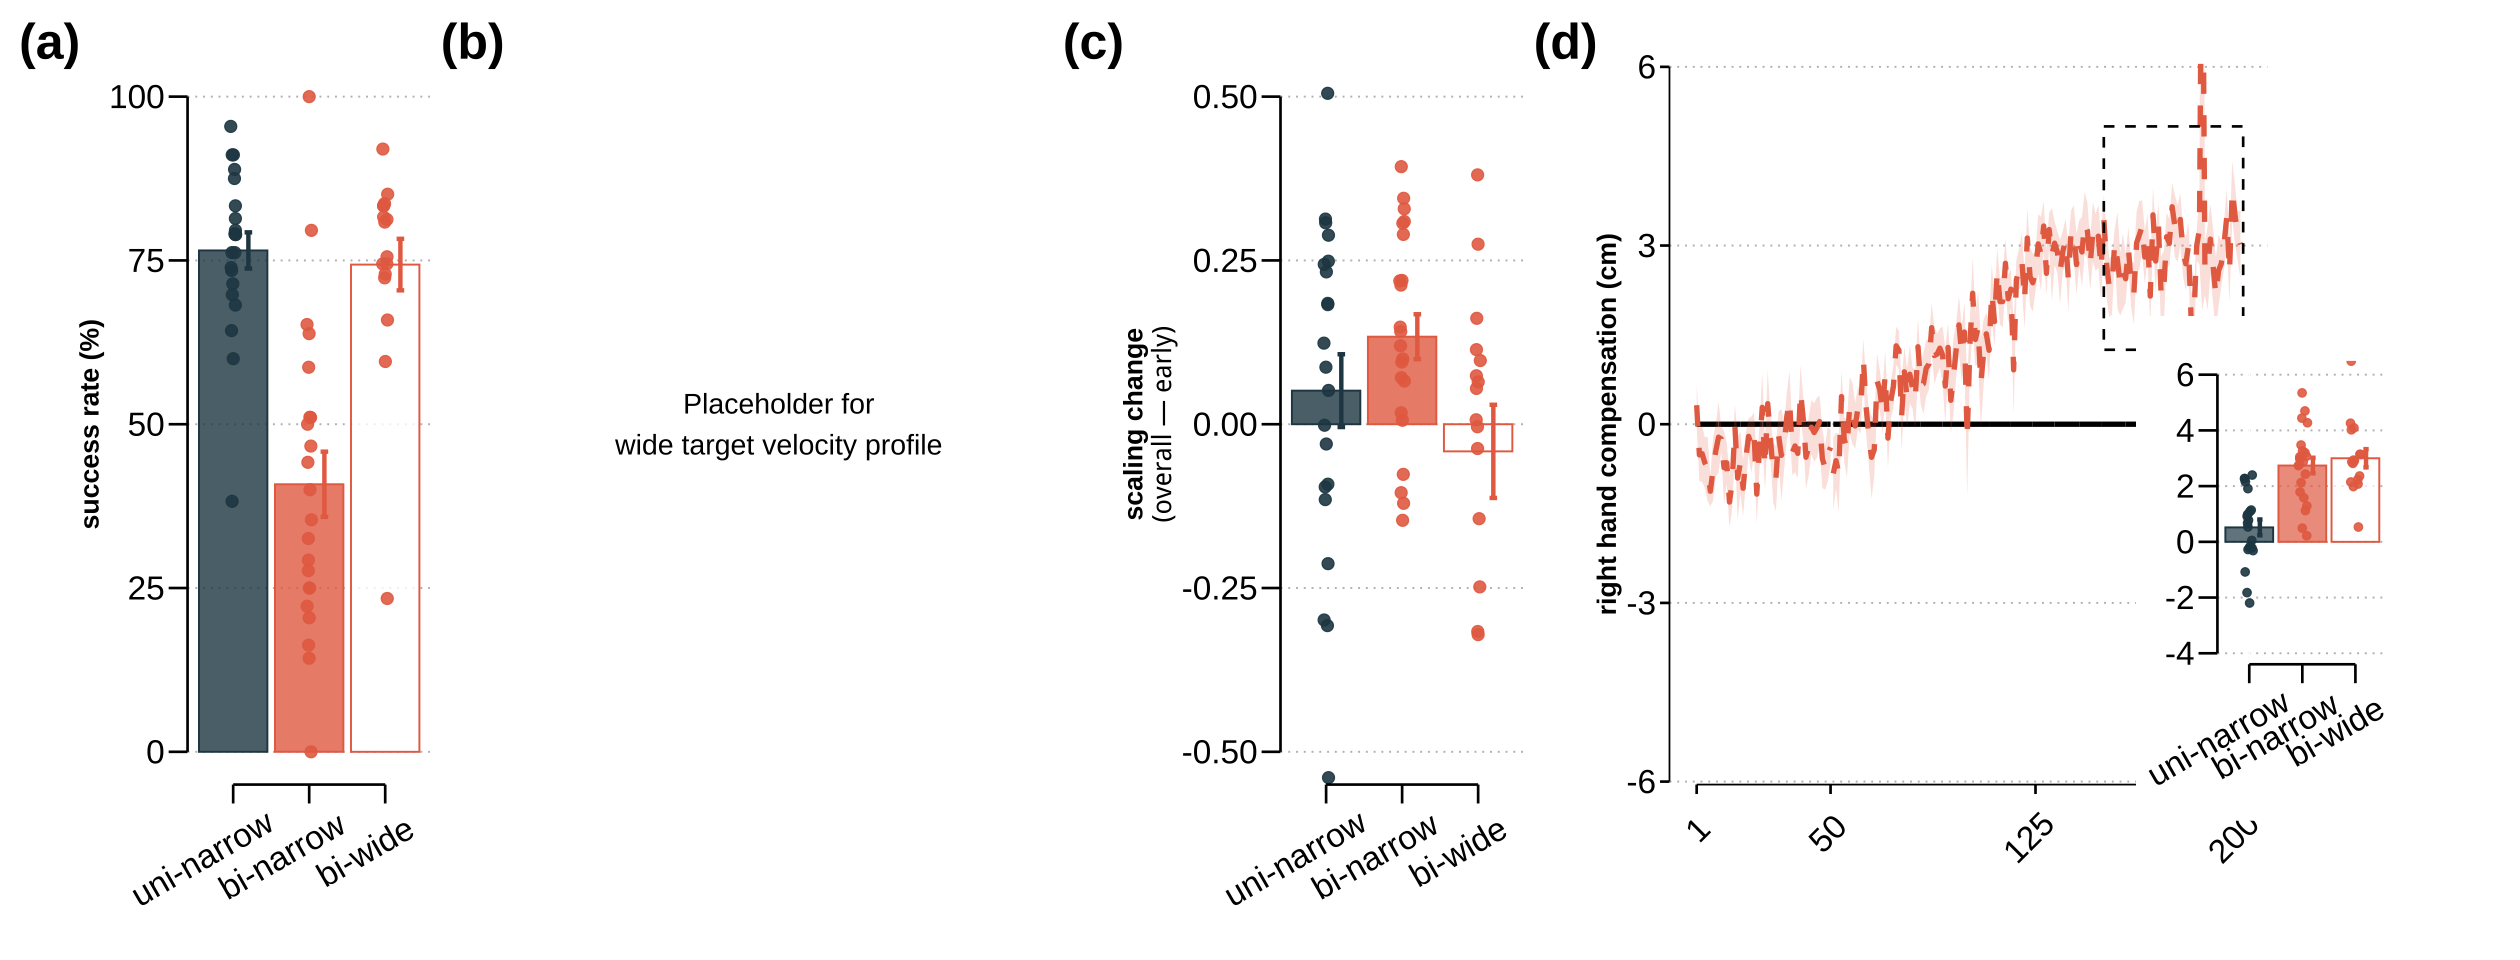

In [29]:
#----------------------------------Fig6-Layout------------------------------------
options(repr.plot.width=21, repr.plot.height=8)

Fig6d_with_inset <- Fig6d + 
  inset_element(Fig6d_inset, left = 0.78, bottom = -0.05, right = 1.2, top = 0.65) 

Fig6 <- Fig6a + Fig6b + Fig6c + Fig6d_with_inset + 
  plot_layout(ncol = 5, widths = c(1.22, 2.75, 1.22, 3)) + 
  plot_annotation(tag_levels = list(c('(a)', '(b)', '(c)', '(d)'))) &  
  theme(plot.tag = element_text(size = 30, face = "bold"))

Fig6

# ggsave(file="Fig6.svg", bg = "transparent", plot=Fig6, width=21, height=8)


### Figure 7
**Bilateral gain perturbation reduces compensations at the hand.**

In [30]:
#----------------------------------Fig7-Plots------------------------------------
#--------------------------------------7a----------------------------------------

Fig7a = ggplot(aes(x = trial, y = tilt_compR_raw*100, group = interaction(gHand, cond), col = gHand, fill = gHand),
        data = dat3 %>% filter(grp == "adults" & tgtHtC == "narrow" & expGrp=="bimanual" & cond != "washout")) +     
    
    coord_capped_cart(ylim = c(-5,5), xlim = c(1, 200), bottom = 'both', left = 'both') +
 
    geom_line(aes(y = 0), col = "black", size = 1.5) +

    stat_summary_bin(geom = "ribbon", fun.data = mean_se, binwidth = 1, lwd = NA, alpha = 0.3, show.legend = FALSE) +
    stat_summary_bin(geom = "line", fun.y = mean, binwidth = 1, lwd = 1.5, alpha = 1, show.legend = FALSE) +
    
    annotate("rect", xmin = 150, xmax = 201, ymin = -1, ymax = 4, fill = NA, 
            color = "black", linetype = "dashed", linewidth = 0.75) +

    scale_color_manual(values = c("r-only" = "#e76f51", "both" = "#779269ff")) +
    scale_fill_manual(values = c("r-only" = "#e76f51", "both" = "#9cbd88ff")) +
    scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
    labs(y = "right hand compensation (cm)", x = "") +

    theme_pubclean() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0), "inches"),
          plot.background = element_blank(),
          panel.border = element_blank(),
          panel.spacing = unit(2, "lines"),
          axis.ticks.length = unit(0.2, "cm"),
          legend.position = "top",
          axis.line.y = element_line(colour = "black"),
          axis.text.x = element_text(angle = 45, vjust = 0.8, hjust = 0.8),
          strip.background = element_blank(),
          plot.title = element_text(hjust = 0.5, size = 14, face = "bold"))

#--------------------------------------7b----------------------------------------

Fig7b = ggplot(aes(x = gHand, y = tilt_compR_raw_mn*100, label = subj, col = gHand, fill = gHand),
        data = summDat2 %>% filter(grp=="adults" & cond3=="end.plateau" & expGrp == "bimanual" & tgtHtC=="narrow")) +

    coord_capped_cart(ylim = c(-5,5), bottom = 'both', left = 'both') +

    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    stat_summary(fun.data = mean_se, geom = "errorbar", position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
    geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend = FALSE) +
    
    scale_x_discrete(labels = c("r-only" = "right-only","both" = "bilateral"),limits = c("r-only", "both")) +
    scale_color_manual(values = c("r-only" = "#e76f51", "both" = "#779269ff")) +
    scale_fill_manual(values = c("r-only" = "#e76f51", "both" = "#9cbd88ff")) +

    labs(x = "", y = "", title = "right hand\ncompensation") +
    theme_pubclean() + thm + 
    theme(plot.margin = unit(c(0, 0, 0, 0), "inches"),
          plot.background = element_blank(),
          panel.border = element_blank(),
          panel.spacing = unit(2, "lines"),
          axis.text.x = element_text(angle = 35, vjust = 1, hjust = 0.8))

#--------------------------------------7c----------------------------------------

Fig7c = ggplot(aes(x = gHand, y = tilt_compL_raw_mn*100, label = subj, col = gHand, fill = gHand),
        data = summDat2 %>% filter(grp=="adults" & cond3=="end.plateau" & expGrp == "bimanual" & tgtHtC=="narrow")) +

    coord_capped_cart(ylim = c(-5,5), bottom = 'both', left = 'both') +

    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    stat_summary(fun.data = mean_se, geom = "errorbar", position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
    geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend = FALSE) +
    
    scale_x_discrete(labels = c("r-only" = "right-only","both" = "bilateral"),limits = c("r-only", "both")) +
    scale_color_manual(values = c("r-only" = "#e76f51", "both" = "#779269ff")) +
    scale_fill_manual(values = c("r-only" = "#e76f51", "both" = "#9cbd88ff")) +

    labs(x = "", y = "", title = "left hand\ncompensation") +
    theme_pubclean() + thm + 
    theme(plot.margin = unit(c(0, 0.5, 0, 0), "inches"),
          plot.background = element_blank(),
          panel.border = element_blank(),
          panel.spacing = unit(2, "lines"),
          axis.text.y = element_blank(),
          axis.text.x = element_text(angle = 35, vjust = 1, hjust = 0.8))


#--------------------------------------7d----------------------------------------

Fig7d = ggplot(aes(x = trial, y = (Py_raw)*100, group = interaction(expGrp, gHand), 
                   col = interaction(expGrp, gHand), fill = interaction(expGrp, gHand)),
             data = dat3 %>% filter(grp=="adults", tgtHtC=="narrow", cond=="washout", 
                                   (gHand=="both" | gHand=="r-only"))) +
    coord_capped_cart(ylim = c(28,40), xlim = c(201, 260), bottom = 'both', left = 'both') +
    stat_summary_bin(geom="ribbon", fun.data = mean_se, binwidth=1, lwd=NA, alpha=0.5, show.legend = FALSE) +
    stat_summary_bin(geom="line", fun.y = mean, binwidth=1, lwd=1.5, alpha=0.9, show.legend = FALSE) +
    
    geom_vline(xintercept = c(211,241), lty = "dashed", col = "gray") +

    scale_x_continuous(breaks = c(1,50,125,200, 260), labels = c("1","50","125","200","260")) +
    
    scale_color_manual(values = c("unimanual.r-only" = "#264653", 
                                 "bimanual.r-only" = "#e76f51",
                                 "bimanual.both" = "#779269ff")) +
    scale_fill_manual(values = c("unimanual.r-only" = "#458999", 
                                "bimanual.r-only" = "#fbad93ff",
                                "bimanual.both" = "#9cbd88ff")) +
    
    annotate("rect", xmin = 200, xmax = 206, ymin = 28, ymax = 37, fill = NA, 
           color = "#404040e3", linetype = "dashed", linewidth = 0.75) +

    labs(x = "", y = "plate displacement (cm)") +
    theme_clean() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0),"inches"),
      plot.background = element_blank(),
      panel.border = element_blank(),
      panel.spacing = unit(2, "lines"),
      axis.ticks.length=unit(0.2,"cm"),
      legend.position="top",
      axis.line.y = element_line(colour = "black"),
      axis.text.x = element_text(angle = 45, vjust = 0.8, hjust=0.8),
      strip.background = element_blank())


#--------------------------------------7d-inset----------------------------------

Fig7d_inset = ggplot(aes(x = factor(interaction(expGrp, gHand), 
                                   levels = c("unimanual.r-only", "bimanual.r-only", "bimanual.both")), 
                         y = Py_raw_mn*100, 
                         col = interaction(expGrp, gHand), fill = interaction(expGrp, gHand)),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="start.washout" & 
                                   (gHand=="both" | gHand=="r-only"))) +

    geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    coord_capped_cart(ylim = c(25,40),bottom = "both",left = "both") +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
    
    scale_x_discrete(labels = c("unimanual.r-only" = "uni", 
                               "bimanual.r-only" = "bi", 
                               "bimanual.both" = "bi\nboth")) +
    
    scale_color_manual(values = c("unimanual.r-only" = "#264653", 
                                 "bimanual.r-only" = "#e76f51",
                                 "bimanual.both" = "#779269ff")) +
    scale_fill_manual(values = c("unimanual.r-only" = "#264653", 
                                "bimanual.r-only" = "#e76f51",
                                "bimanual.both" = "#779269ff")) +
    
    labs(x = "", y = "") + # plate displacement (cm) removed label
    theme_pubclean() + thm



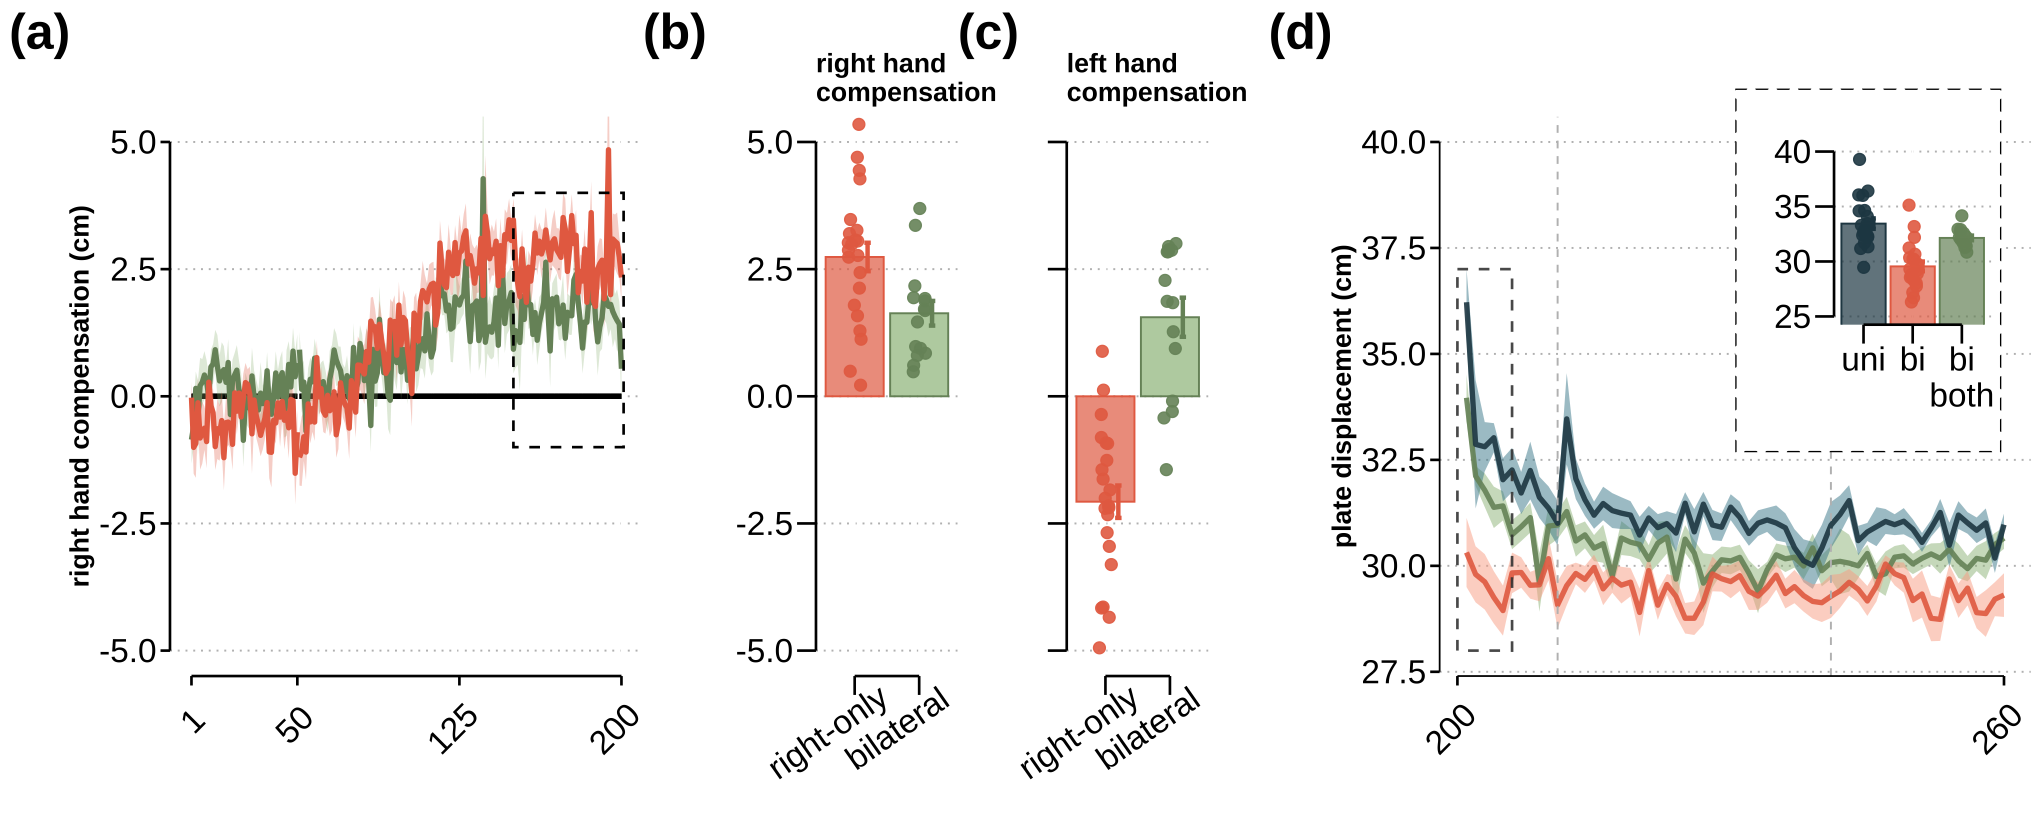

In [31]:
#----------------------------------Fig7-Layout------------------------------------
options(repr.plot.width=17, repr.plot.height=7)

Fig7d_with_inset <- Fig7d + 
  inset_element(Fig7d_inset, left = 0.5, bottom = 0.4, right = 0.95, top = 1.05)+
  theme(plot.background = element_rect(fill = "white", color = "black", linetype = "dashed", size = 0.75))

Fig7 <- Fig7a + Fig7b + Fig7c + Fig7d_with_inset + #Fig7c (did not include L trialseries) + 
  plot_layout(ncol = 4, nrow = 1, widths = c(3, 0.9, 0.9, 3.75), heights = c(1, 1, 1, 1)) + 
  plot_annotation(tag_levels = list(c('(a)','(b)','(c)','(d)'))) &
  theme(plot.tag = element_text(size = 30, face = "bold"))

Fig7

# ggsave(file="Fig7_new2.svg", bg = "transparent", plot=Fig7, width=17, height=7)

## Statistics

### Unimanual group was more successful than bimanual group.

In [32]:
statDat1 = summDat2 %>% filter(grp == "adults" & tgtHtC=="narrow" & gHand=="r-only" & cond3=="end.plateau")
statDat_0 = summDat2 %>% filter(grp == "adults" & tgtHtC=="narrow" & gHand=="r-only")

In [33]:
# 1.During the learning block, success rate decreased in both groups as the perturbation was ramped down, and the pattern of decrease mirrored the perturbation and was similar across both groups.
stat1 = rlm(succRate~expGrp, data = statDat1) 
stat1 %>% Anova(.)

# 2.Although target size was the same, success rate was significantly lower in the bimanual group compared to the unimanual group, with a mean difference of 35.7 ± 5.8% at the end of adaptation phase (Fig 2b). 
emmeans(stat1, ~ expGrp) %>% tidy(.)
pairs(emmeans(stat1, ~ expGrp),adjust = "bonferroni") %>% tidy(.)

# 3.Why was success rate significantly lower in the bimanual group? The bimanual group had stricter requirements (both edges and center in target zone) compared to unimanual (center only, see Methods for error calculations). We found that the bimanual group's lower success rate was partly due to plate alignment errors (r = 0.62; p=0.002; Fig 2c). 
statDat1 %>% 
  group_by(expGrp) %>%
  summarize(r = cor(succRate, final_plateAlign_raw_mn),
            p = cor.test(succRate, final_plateAlign_raw_mn)$p.value,
            n = n())
  

,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>
expGrp,1,53.95008,5.391252e-09
Residuals,41,NA,NA


expGrp,estimate,std.error,df,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
unimanual,77.31967,3.753729,NA,20.59809,2.854594e-94
bimanual,38.77344,3.667425,NA,10.57239,4.001722e-26


term,contrast,null.value,estimate,std.error,df,statistic,p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
expGrp,unimanual - bimanual,0,38.54623,5.247904,NA,7.345072,2.056491e-13


expGrp,r,p,n
<fct>,<dbl>,<dbl>,<int>
unimanual,0.1913625,0.40599852,21
bimanual,0.6221596,0.00198992,22


### Uni- and bimanual groups used different movement strategies to adapt to the perturbation.

In [34]:
display_markdown("### Comparing right rand DISPLACEMENT")
# 1.Both groups showed similar learning patterns, gradually increasing right-hand displacement over the adaptation phase (Fig 3a). However, by the end of adaptation, the unimanual group moved their right hand significantly higher than the bimanual group (approximately 43cm vs 40cm, p = Fig 3b).
stat2 = rlm(Ry_raw_mn*100 ~ expGrp, data = statDat1) 
stat2 %>% Anova(.)

emmeans(stat2, ~ expGrp) %>% tidy()
pairs(emmeans(stat2, ~ expGrp)) %>% tidy(.)

# 2.This difference in right-hand movement had functional consequences for plate control. In the unimanual group, participants who moved their right hand higher showed better plate center alignment within the target, i.e., less undershooting (Fig 3c). However, the bimanual group showed no relationship between right-hand displacement and plate alignment.
statDat1 %>% 
  group_by(expGrp) %>%
  summarize(r = cor(Ry_raw_mn, final_plateAlign_raw_mn),
            p = cor.test(Ry_raw_mn, final_plateAlign_raw_mn)$p.value,
            n = n())

#----------------------------------

display_markdown("<br><br>")
display_markdown("### Comparing right hand COMPENSATION")
# 3.The bimanual group progressively developed these hand compensations throughout adaptation (Fig 3e) and showed significantly more compensations than the unimanual group by the end of learning (Fig 3f). 
stat3 = rlm(tilt_compR_raw_mn*100 ~ expGrp, data = statDat1)
stat3 %>% Anova(.)

emmeans(stat3, ~ expGrp) %>% tidy()
pairs(emmeans(stat3, ~ expGrp),adjust = "bonferroni") %>% tidy(.)


### Comparing right rand DISPLACEMENT

,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>
expGrp,1,31.31034,1.624561e-06
Residuals,41,NA,NA


expGrp,estimate,std.error,df,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
unimanual,43.85112,0.4785768,NA,91.62818,0
bimanual,40.10727,0.4675735,NA,85.77746,0


term,contrast,null.value,estimate,std.error,df,statistic,p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
expGrp,unimanual - bimanual,0,3.743849,0.6690745,NA,5.595564,2.199059e-08


expGrp,r,p,n
<fct>,<dbl>,<dbl>,<int>
unimanual,0.44320283,0.04419183,21
bimanual,-0.04443213,0.84434677,22


<br><br>

### Comparing right hand COMPENSATION

,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>
expGrp,1,22.05639,2.961218e-05
Residuals,41,NA,NA


expGrp,estimate,std.error,df,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
unimanual,0.603144,0.3264587,NA,1.847535,6.466959e-02
bimanual,2.746619,0.3189529,NA,8.611362,7.219772e-18


term,contrast,null.value,estimate,std.error,df,statistic,p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
expGrp,unimanual - bimanual,0,-2.143475,0.4564058,NA,-4.696424,2.647563e-06


### Unimanual group showed larger aftereffects in displacement than bimanual group.

In [35]:
statDat2 = summDat2 %>% filter(grp == "adults" & tgtHtC=="narrow" & gHand=="r-only" & cond3=="start.washout")
statDat2_widen = summDat2_wide %>% filter(grp == "adults" & tgtHtC=="narrow" & gHand=="r-only")

In [36]:
stat4 = rlm(Ry_raw_mn*100 ~ expGrp, data = statDat2) 
stat4 %>% Anova(.)

#get expGrp-wise baseline means to insert as null values in comparison
display_markdown("### Comparing RIGHT HAND aftereffects to group-wise baseline means")
MN_Ry_raw_BM = summDat2 %>% filter(grp == "adults" & tgtHtC=="narrow" & gHand=="r-only" & expGrp=="bimanual" & cond3=="baseline") %>% summarize(MN_Ry_raw_BM = mean(Ry_raw_mn)*100) %>% pull(MN_Ry_raw_BM)
MN_Ry_raw_UM = summDat2 %>% filter(grp == "adults" & tgtHtC=="narrow" & gHand=="r-only" & expGrp=="unimanual" & cond3=="baseline") %>% summarize(MN_Ry_raw_UM = mean(Ry_raw_mn)*100) %>% pull(MN_Ry_raw_UM)

# 1.Both groups showed aftereffects in right hand displacement, 
emmeans(stat4, ~ expGrp, at = list(expGrp = "bimanual")) %>% test(null = MN_Ry_raw_BM) %>% tidy()
emmeans(stat4, ~ expGrp, at = list(expGrp = "unimanual")) %>% test(null = MN_Ry_raw_UM) %>% tidy()

# 2. but these aftereffects were larger in the unimanual compared to bimanual group (mean difference of 2cm, t (41) = 2.5, p=0.012; Fig 4a). Only the unimanual group showed aftereffects in plate displacement while there were little to no plate aftereffects in the bimanual group (mean difference of 3.8cm, t (41) = 6.5, p<0.001; Fig 4b). Aftereffects seemed to last longer and reappeared after breaks in the unimanual group.
display_markdown("### Comparing RIGHT HAND aftereffects between groups")
emmeans(stat4, ~ expGrp) %>% tidy()
pairs(emmeans(stat4, ~ expGrp),adjust = "bonferroni") %>% tidy(.)


display_markdown("<br><br>")
stat5 = rlm(Py_raw_mn*100 ~ expGrp, data = statDat2) 
stat5 %>% Anova(.)
#get expGrp-wise baseline means to insert as null values in comparison
display_markdown("### Comparing PLATE aftereffects to group-wise baseline means")
MN_Py_raw_BM = summDat2 %>% filter(grp == "adults" & tgtHtC=="narrow" & gHand=="r-only" & expGrp=="bimanual" & cond3=="baseline") %>% summarize(MN_Py_raw_BM = mean(Py_raw_mn)*100) %>% pull(MN_Py_raw_BM)
MN_Py_raw_UM = summDat2 %>% filter(grp == "adults" & tgtHtC=="narrow" & gHand=="r-only" & expGrp=="unimanual" & cond3=="baseline") %>% summarize(MN_Py_raw_UM = mean(Py_raw_mn)*100) %>% pull(MN_Py_raw_UM)

# 1.Both groups showed aftereffects in right hand displacement, 
emmeans(stat5, ~ expGrp, at = list(expGrp = "bimanual")) %>% test(null = MN_Py_raw_BM) %>% tidy()
emmeans(stat5, ~ expGrp, at = list(expGrp = "unimanual")) %>% test(null = MN_Py_raw_UM) %>% tidy()

display_markdown("### Comparing PLATE aftereffects between groups")
emmeans(stat5, ~ expGrp) %>% tidy()
pairs(emmeans(stat5, ~ expGrp),adjust = "bonferroni") %>% tidy(.)

# 2.In the bimanual group, those who adapted more completely (had greater hand displacement) during learning showed larger aftereffects (r = 0.52, p=0.005). However, no such relationship existed in the unimanual group (r = -0.15, p=0.59) (Fig 4c). 
display_markdown("<br><br>")
display_markdown("### Correlations between right hand adaptation and aftereffects")
statDat2_widen %>% 
  group_by(expGrp) %>%
  summarize(r = cor(Ry_raw_mn_end.plateau, Ry_raw_mn_start.washout),
            p = cor.test(Ry_raw_mn_end.plateau, Ry_raw_mn_start.washout)$p.value,
            n = n())


,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>
expGrp,1,6.294813,0.01615572
Residuals,41,NA,NA


### Comparing RIGHT HAND aftereffects to group-wise baseline means

expGrp,estimate,std.error,df,null,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
bimanual,31.263,0.5488288,NA,29.69167,2.863073,0.004195532


expGrp,estimate,std.error,df,null,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
unimanual,33.2334,0.5617442,NA,30.41434,5.0184,5.210351e-07


### Comparing RIGHT HAND aftereffects between groups

...

expGrp,estimate,std.error,df,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
unimanual,33.19721,0.4250257,NA,78.10636,0
bimanual,29.34254,0.4152537,NA,70.66172,0


term,contrast,null.value,estimate,std.error,df,statistic,p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
expGrp,unimanual - bimanual,0,3.854671,0.5942074,NA,6.48708,8.751605e-11


<br><br>

### Correlations between right hand adaptation and aftereffects

expGrp,r,p,n
<fct>,<dbl>,<dbl>,<int>
unimanual,-0.1241820,0.591743703,21
bimanual,0.5742774,0.005188485,22


### Bimanual group used more feedback control than unimanual group.

In [37]:
statDat3 = summDat2 %>% filter(grp == "adults" & tgtHtC=="narrow" & gHand=="r-only" & !cond3%in%c("start.washout","end.washout"))
statDat3_long = elong1 %>% filter(percDist%in%c(20,100)) %>% mutate(percDist = as.factor(percDist)) %>% 
                           filter(hand=="right" & tgtHtC=="narrow" & grp=="adults" & gHand=="r-only" & !cond3%in%c("start.washout","end.washout"))
statDat3_widen = summDat2_wide %>% filter(grp == "adults" & tgtHtC=="narrow" & gHand=="r-only")


In [38]:
# 1.Consistent with a feedback-control policy, the bimanual group showed lower peak speeds than the unimanual group. While groups did not differ at baseline, significant differences emerged during learning (mean difference ≈0.1m/s, p<0.05; Fig 5a). 
display_markdown("### Comparing peak speed - bimanual vs unimanual")
stat5 = rlmer(peakspeedR_raw_mn~expGrp*cond3 + (1|subj), data = statDat3) 
pairs(emmeans(stat5, ~ expGrp|cond3),adjust = "bonferroni") %>% tidy(.)

# 3.The unimanual group showed relatively uniform scaling across the movement, whereas the bimanual group exhibited a more gradual increase in speed scaling, with greater overall scaling compared to early scaling
display_markdown("<br><br>")
display_markdown("### Comparing EARLY to OVERALL speed scaling change across learning - bimanual vs unimanual")
stat6 = rlmer(data = statDat3_long, speed ~ expGrp * percDist * cond3 + (1|subj))
emm6 = emmeans(stat6, ~ percDist * expGrp | cond3)
emm6 %>% tidy(.)
adjusted_contrast = contrast(emm6, interaction = "pairwise") %>% tidy()
adjusted_contrast$p.bonf = p.adjust(adjusted_contrast$p.value, method = "bonferroni")
adjusted_contrast

# confirmation by comparing scaling_change to 0.
stat6b = rlm(scaling_changeR_corr_mn ~ expGrp, data = statDat3 %>% filter(cond3=="end.plateau")) 
emmeans(stat6b, ~ expGrp) %>% test(null = 0) %>% tidy()

# 4.The magnitude of change in scaling (difference between early and overall scaling) significantly predicted early speed aftereffects
display_markdown("<br><br>")
display_markdown("### Correlations between right hand scaling-change and early speed aftereffects")
statDat3_widen %>% 
  summarize(r = cor(scaling_changeR_corr_mn_end.plateau, slopesR2_corr_mn_start.washout),
            p = cor.test(scaling_changeR_corr_mn_end.plateau, slopesR2_corr_mn_start.washout)$p.value,
            n = n())
            

### Comparing peak speed - bimanual vs unimanual

cond3,term,contrast,null.value,estimate,std.error,df,statistic,p.value
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
baseline,expGrp,unimanual - bimanual,0,0.09178064,0.04852833,Inf,1.891280,0.05858703
start.ramp,expGrp,unimanual - bimanual,0,0.10971301,0.04852833,Inf,2.260803,0.02377144
end.ramp,expGrp,unimanual - bimanual,0,0.12284615,0.04852833,Inf,2.531432,0.01135980
start.plateau,expGrp,unimanual - bimanual,0,0.10051765,0.04852833,Inf,2.071319,0.03832900
end.plateau,expGrp,unimanual - bimanual,0,0.11122874,0.04852833,Inf,2.292037,0.02190349


<br><br>

### Comparing EARLY to OVERALL speed scaling change across learning - bimanual vs unimanual

percDist,expGrp,cond3,estimate,std.error,df,statistic,p.value
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
20,unimanual,baseline,1.004729,0.05424535,Inf,18.52194,1.373932e-76
100,unimanual,baseline,1.011408,0.05424535,Inf,18.64506,1.384939e-77
20,bimanual,baseline,1.008557,0.05309557,Inf,18.99513,1.871172e-80
100,bimanual,baseline,1.008929,0.05309557,Inf,19.00213,1.637542e-80
20,unimanual,start.ramp,1.080279,0.05164333,Inf,20.91807,3.666394e-97
100,unimanual,start.ramp,1.058955,0.05164333,Inf,20.50516,1.936321e-93
20,bimanual,start.ramp,1.013862,0.05045598,Inf,20.09399,8.329497e-90
100,bimanual,start.ramp,1.046055,0.05045598,Inf,20.73204,1.780818e-95
20,unimanual,end.ramp,1.105162,0.05179179,Inf,21.33856,4.980891e-101


cond3,term,percDist_pairwise,expGrp_pairwise,estimate,std.error,df,statistic,p.value,p.bonf
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
baseline,percDist*expGrp,20 - 100,unimanual - bimanual,-0.006307037,0.04302442,Inf,-0.1465920,0.883454050,1.00000000
start.ramp,percDist*expGrp,20 - 100,unimanual - bimanual,0.053517644,0.02744672,Inf,1.9498740,0.051191135,0.25595567
end.ramp,percDist*expGrp,20 - 100,unimanual - bimanual,0.008168179,0.02844815,Inf,0.2871252,0.774016486,1.00000000
start.plateau,percDist*expGrp,20 - 100,unimanual - bimanual,0.066937189,0.02894314,Inf,2.3127132,0.020738415,0.10369208
end.plateau,percDist*expGrp,20 - 100,unimanual - bimanual,0.058887098,0.02018818,Inf,2.9169092,0.003535187,0.01767593


expGrp,estimate,std.error,df,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
unimanual,0.06361249,0.04494285,NA,1.415408,0.156948774
bimanual,0.13360209,0.04390955,NA,3.042666,0.002344923


<br><br>

### Correlations between right hand scaling-change and early speed aftereffects

r,p,n
<dbl>,<dbl>,<int>
-0.45705,0.002062415,43


### Wide target improved bimanual success and reduced feedback reliance, but hand compensations persisted.

In [39]:
statDat4_ad = summDat2 %>% filter(grp == "adults" & expGrp=="bimanual" & gHand=="r-only" & cond3=="end.plateau")
statDat4_wo = summDat2 %>% filter(grp == "adults" & expGrp=="bimanual" & gHand=="r-only" & cond3=="start.washout")

statDat4_long = elong1 %>% filter(percDist%in%c(20,100)) %>% mutate(percDist = as.factor(percDist)) %>% 
                           filter(hand=="right" & expGrp=="bimanual" & grp=="adults" & gHand=="r-only" & !cond3%in%c("start.washout","end.washout"))


In [40]:
# 1.Widening the target substantially improved success rates in the bimanual group (Fig 6a), with the wide target group achieving success rates that approached those of the unimanual group.
display_markdown("### Comparing SUCCESS RATES - narrow vs wide")
stat7 = rlm(succRate~tgtHtC, data = statDat4_ad) 
stat7 %>% Anova(.)
emmeans(stat7, ~ tgtHtC) %>% tidy(.)
pairs(emmeans(stat7, ~ tgtHtC)) %>% tidy(.)

# 2.These performance improvements occurred without changes to:  That is, the wide target altered control strategies without affecting motor execution or learning.
# peak speed,
display_markdown("<br><br>")
display_markdown("### Comparing peak speed - narrow vs wide")
stat8a = rlm(peakspeedR_raw_mn~tgtHtC, data = statDat4_ad) 
pairs(emmeans(stat8a, ~ tgtHtC)) %>% tidy(.)
# movement time,
display_markdown("### Comparing movt. time - narrow vs wide")
stat8b = rlm(mt_raw_mn~tgtHtC, data = statDat4_ad) 
pairs(emmeans(stat8b, ~ tgtHtC)) %>% tidy(.)
# or displacement aftereffects.
display_markdown("### Comparing RIGHT hand DISP aftereffects - narrow vs wide")
stat8c = rlm(Ry_raw_mn~tgtHtC, data = statDat4_wo) 
pairs(emmeans(stat8c, ~ tgtHtC)) %>% tidy(.)

# 3.Like the unimanual group, the bimanual-wide group showed relatively uniform speed scaling (Fig 6b) with minimal change between early and overall scaling (Fig 6c), suggesting less reliance on feedback control.
display_markdown("<br><br>")
display_markdown("### Comparing EARLY to OVERALL speed scaling change across learning - narrow vs wide")
stat9 = rlmer(data = statDat4_long, speed ~ tgtHtC * percDist * cond3 + (1|subj))
emm9 = emmeans(stat9, ~ percDist * tgtHtC | cond3)
emm9 %>% tidy(.)
contrast(emm9, interaction = "pairwise") %>% tidy(.) #DiD

# confirmation by comparing scaling_change to 0.
stat9b = rlm(scaling_changeR_corr_mn ~ tgtHtC, data = statDat4_ad) 
emmeans(stat9b, ~ tgtHtC) %>% test(null = 0) %>% tidy()

# 4.Despite improved success and reduced feedback reliance, hand compensations persisted. That is, people continued to compensate by tilting or rotating the right hand throughout adaptation (Fig 6d), reaching similar magnitudes to the narrow target bimanual group by the end of learning (Fig 6d inset).
display_markdown("<br><br>")
display_markdown("### Comparing TILT compensations - narrow vs wide")
stat10 = rlm(tilt_compR_raw_mn*100 ~ tgtHtC, data = statDat4_ad)
stat10 %>% Anova(.)

emmeans(stat10, ~ tgtHtC) %>% tidy()
pairs(emmeans(stat10, ~ tgtHtC)) %>% tidy(.)

### Comparing SUCCESS RATES - narrow vs wide

,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>
tgtHtC,1,42.00946,1.587256e-07
Residuals,36,NA,NA


tgtHtC,estimate,std.error,df,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
narrow,38.70882,3.766747,NA,10.27646,8.997294e-25
wide,76.33341,4.416902,NA,17.28211,6.415233e-67


term,contrast,null.value,estimate,std.error,df,statistic,p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
tgtHtC,narrow - wide,0,-37.62459,5.804947,NA,-6.481471,9.08329e-11


<br><br>

...

<br><br>

### Comparing TILT compensations - narrow vs wide

,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>
tgtHtC,1,0.1899994,0.6655199
Residuals,36,NA,NA


tgtHtC,estimate,std.error,df,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
narrow,2.741401,0.2771130,NA,9.892720,4.476938e-23
wide,2.927552,0.3249438,NA,9.009411,2.071663e-19


term,contrast,null.value,estimate,std.error,df,statistic,p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
tgtHtC,narrow - wide,0,-0.1861507,0.4270598,NA,-0.4358892,0.6629171


### Bilateral gain perturbation reduced hand compensations and led to larger plate aftereffects.

In [41]:
statDat5_ad = summDat2 %>% filter(grp == "adults" & expGrp=="bimanual" & tgtHtC=="narrow" & cond3=="end.plateau")
statDat5_wo = summDat2 %>% filter(grp == "adults" & expGrp=="bimanual" & tgtHtC=="narrow" & cond3=="start.washout")

# for comparison to unimanual
statDat5b_wo <- summDat2 %>% 
  filter(grp == "adults" & tgtHtC == "narrow" & cond3 == "start.washout") %>%
  filter((expGrp == "bimanual" & gHand == "both") | 
         (expGrp == "unimanual" & gHand == "r-only"))

In [43]:
display_markdown("### Comparing RIGHT hand compensation")
stat11a = rlm(tilt_compR_raw_mn*100 ~ gHand, data = statDat5_ad)
stat11a %>% Anova(.)

emm11a = emmeans(stat11a, ~ gHand) 
test(emm11a, null = 0)
pairs(emmeans(stat11a, ~ gHand)) %>% tidy(.)

display_markdown("<br><br>")
display_markdown("### Comparing LEFT hand compensation")
stat11b = rlm(tilt_compL_raw_mn*100 ~ gHand, data = statDat5_ad)
stat11b %>% Anova(.)

emm11b = emmeans(stat11b, ~ gHand) 
test(emm11b, null = 0)
pairs(emmeans(stat11b, ~ gHand)) %>% tidy(.)

display_markdown("<br><br>")
display_markdown("### Comparing PLATE aftereffects")
stat12 = rlm(Py_raw_mn*100 ~ gHand, data = statDat5_wo)
stat12 %>% Anova(.)

emmeans(stat12, ~ gHand) %>% tidy()
pairs(emmeans(stat12, ~ gHand)) %>% tidy(.)

display_markdown("<br><br>")
display_markdown("### Comparing PLATE aftereffects with UNIMANUAL")
stat13 <- rlm(Py_raw_mn * 100 ~ expGrp, data = statDat5b_wo)
Anova(stat13)

emmeans(stat13, ~ expGrp) %>% tidy()
pairs(emmeans(stat13, ~ expGrp)) %>% tidy()

### Comparing RIGHT hand compensation

,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>
gHand,1,9.920947,0.003337386
Residuals,35,NA,NA


,gHand,emmean,SE,df,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,both,1.529451,0.2966871,NA,5.155099,2.534974e-07
2,r-only,2.741345,0.2449813,NA,11.190019,4.563338e-29


term,contrast,null.value,estimate,std.error,df,statistic,p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
gHand,both - (r-only),0,-1.211894,0.3847584,NA,-3.149754,0.001634083


<br><br>

...

<br><br>

### Comparing PLATE aftereffects with UNIMANUAL

,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>
expGrp,1,5.380025,0.02650859
Residuals,34,NA,NA


expGrp,estimate,std.error,df,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
unimanual,33.15384,0.2903978,NA,114.16696,0
bimanual,32.11034,0.3436033,NA,93.45177,0


term,contrast,null.value,estimate,std.error,df,statistic,p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
expGrp,unimanual - bimanual,0,1.043497,0.4498824,NA,2.319488,0.02036859


## Supplement

### S1: No left hand aftereffects in bimanual-narrow group

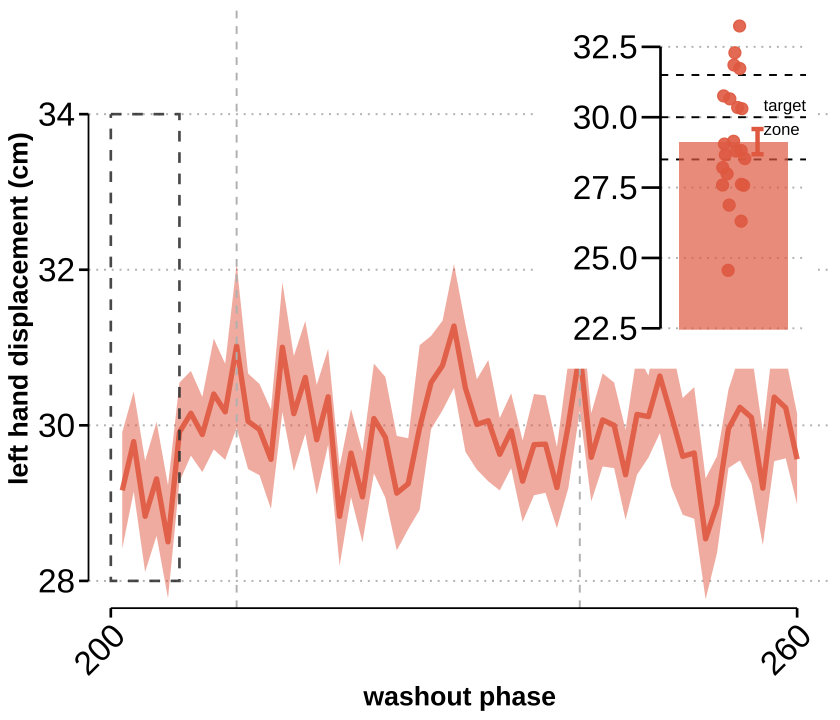

In [46]:
FigS1a = ggplot(aes(x = trial,y = (Ly_raw)*100, group=interaction(cond,tgtHtC,gHand)),
                data = dat3 %>% filter(grp=="adults" & cond=="washout" & tgtHtC=="narrow" & gHand=="r-only" & expGrp=="bimanual")) +
    coord_capped_cart(ylim = c(28,35), xlim = c(201, 260), bottom = 'both', left = 'both') +
    stat_summary_bin(geom="ribbon", fill = "#e76f51", fun.data = mean_se, binwidth=1,lwd=NA,alpha=0.5,show.legend = FALSE) +
    stat_summary_bin(geom="line",col = "#e76f51", fun.y = mean,binwidth=1,lwd=1.5,alpha=0.9,show.legend = FALSE) +

    geom_vline(xintercept = c(211,241),lty = "dashed", col = "gray") +
    scale_x_continuous(breaks = c(1,50,125,200, 260), labels = c("1","50","125","200","260")) +
    
    annotate("rect", xmin = 200, xmax = 206, ymin = 28, ymax = 34, fill = NA, 
            color = "#404040e3", linetype = "dashed", linewidth = 0.75) +

    labs(x = "washout phase", y = "left hand displacement (cm)") +
    theme_clean() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0),"inches"),
      plot.background = element_blank(),
      panel.border = element_blank(),
      panel.spacing = unit(2, "lines"),
      axis.ticks.length=unit(0.2,"cm"),
      axis.text.x = element_text(angle = 45, hjust = 1),
      legend.position="top",
      axis.line.y = element_line(colour = "black"))

FigS1b = ggplot(aes(x = expGrp, y = Ly_raw_mn*100),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & expGrp=="bimanual" & cond3=="start.washout" & gHand=="r-only")) +
    coord_capped_cart(ylim = c(23,34),bottom = "both",left = "both") +
    geom_hline(yintercept = c(28.5,30, 31.5), lty="dashed") +        
    geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), col = "#e76f51", alpha = 0.9, size = 3, show.legend =FALSE) +
    stat_summary(fun = mean, geom = "bar", fill = "#e76f51",position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    stat_summary(fun.data = mean_se, col = "#e76f51", geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
    annotate("text", x = 1.25, y = 30, label = "target\nzone", hjust = 0, size = 3.5, color = "black") +  
    labs(x = "", y = "") + 
    theme_pubclean() + thm +
    theme(axis.text.x = element_blank(),axis.ticks.x = element_blank())

options(repr.plot.width=7, repr.plot.height=6)
FigS1a + inset_element(FigS1b, left = 0.6, bottom = 0.4, right = 0.98, top = 1.05)


### S2: narrow vs wide peak speed, movement time, and displacement aftereffects

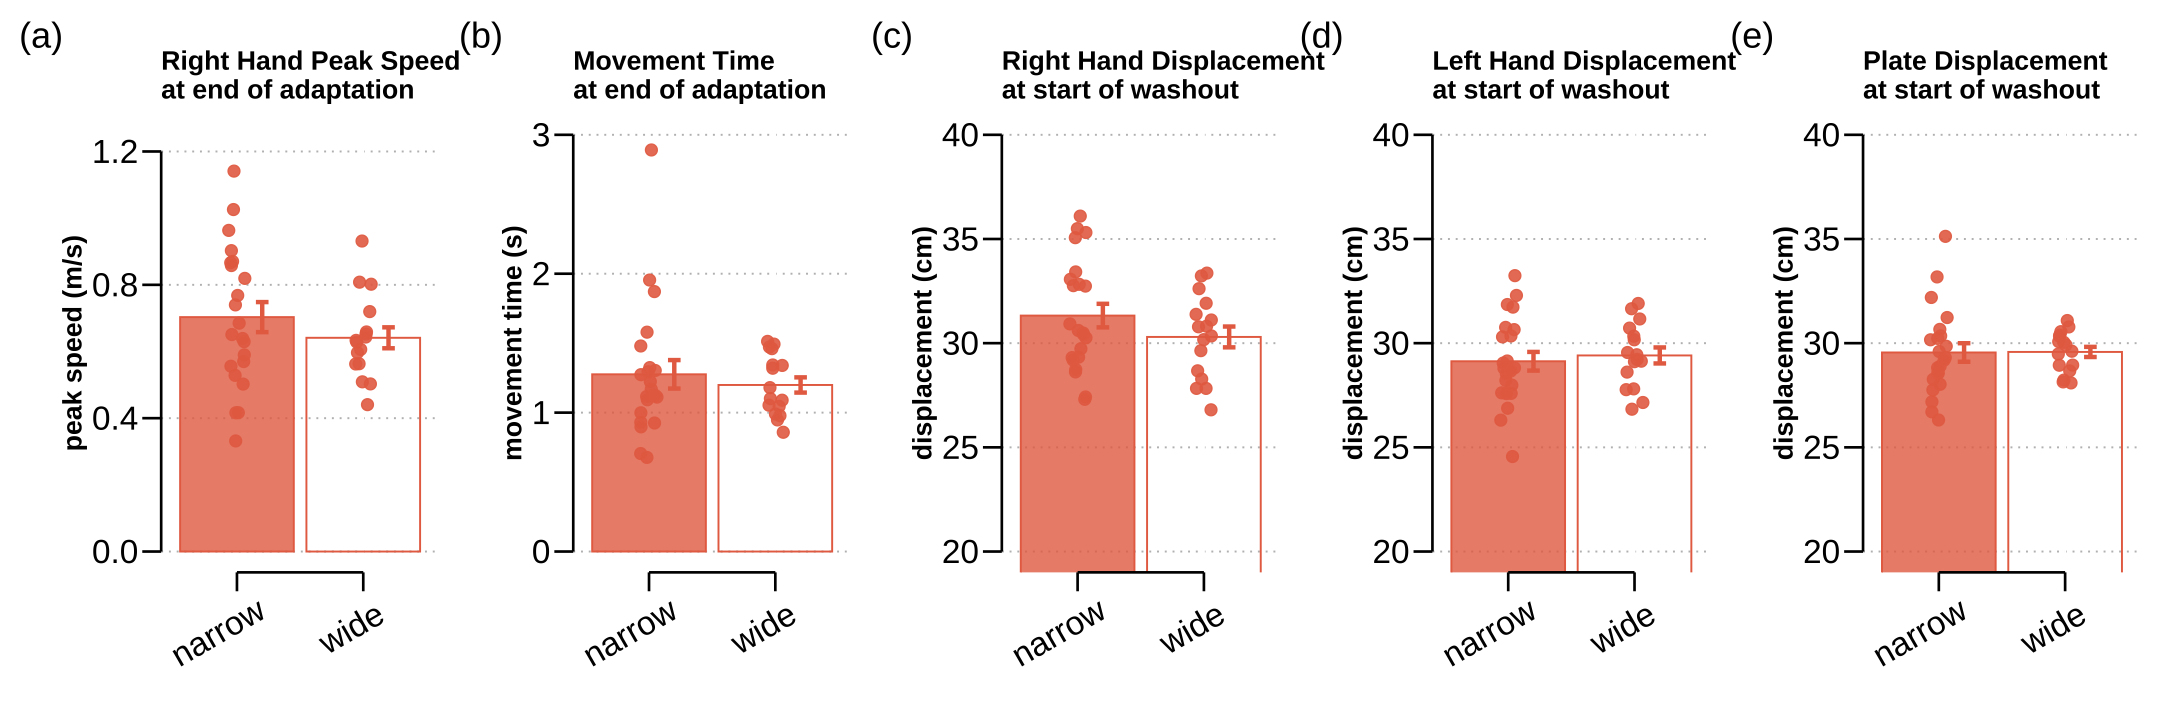

In [47]:
FigS2a = ggplot(aes(x = tgtHtC, y = peakspeedR_raw_mn, group = tgtHtC, col = tgtHtC, fill = tgtHtC),
        data = summDat2 %>% filter(grp=="adults" & gHand=="r-only" & expGrp=="bimanual" & cond3=="end.plateau")) +
    coord_capped_cart(ylim = c(0,1.25),bottom = "both",left = "both") +
    
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), stroke = 1.5, 
                 size = 1.2, show.legend = FALSE, alpha = 0.8) +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, 
                 linewidth = 1.25, show.legend = FALSE) +
    geom_point(position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    
    scale_color_manual(values = c("narrow" = "#e76f51", "wide" = "#e76f51")) +
    scale_fill_manual(values = c("narrow" = "#e76f51", "wide" = NA)) +
  
    labs(x = "", y = "peak speed (m/s)", title = "Right Hand Peak Speed\nat end of adaptation") +
    
    theme_pubclean() + thm  + 
    theme(axis.text.x = element_text(angle = 30, vjust = 0.75, hjust = 0.75))

FigS2b = ggplot(aes(x = tgtHtC, y = mt_raw_mn, group = tgtHtC, col = tgtHtC, fill = tgtHtC),
        data = summDat2 %>% filter(grp=="adults" & gHand=="r-only" & expGrp=="bimanual" & cond3=="end.plateau")) +
    coord_capped_cart(ylim = c(0,3),bottom = "both",left = "both") +
    
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), stroke = 1.5, 
                 size = 1.2, show.legend = FALSE, alpha = 0.8) +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, 
                 linewidth = 1.25, show.legend = FALSE) +
    geom_point(position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    
    scale_color_manual(values = c("narrow" = "#e76f51", "wide" = "#e76f51")) +
    scale_fill_manual(values = c("narrow" = "#e76f51", "wide" = NA)) +
  
    labs(x = "", y = "movement time (s)", title = "Movement Time\nat end of adaptation") +
    
    theme_pubclean() + thm  + 
    theme(axis.text.x = element_text(angle = 30, vjust = 0.75, hjust = 0.75))

FigS2c = ggplot(aes(x = tgtHtC, y = Ry_raw_mn*100, group = tgtHtC, col = tgtHtC, fill = tgtHtC),
        data = summDat2 %>% filter(grp=="adults" & gHand=="r-only" & expGrp=="bimanual" & cond3=="start.washout")) +
    coord_capped_cart(ylim = c(20,40),bottom = "both",left = "both") +
    
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), stroke = 1.5, 
                 size = 1.2, show.legend = FALSE, alpha = 0.8) +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, 
                 linewidth = 1.25, show.legend = FALSE) +
    geom_point(position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    
    scale_color_manual(values = c("narrow" = "#e76f51", "wide" = "#e76f51")) +
    scale_fill_manual(values = c("narrow" = "#e76f51", "wide" = NA)) +
  
    labs(x = "", y = "displacement (cm)", title = "Right Hand Displacement\nat start of washout") +
    
    theme_pubclean() + thm  + 
    theme(axis.text.x = element_text(angle = 30, vjust = 0.75, hjust = 0.75))

FigS2d = ggplot(aes(x = tgtHtC, y = Ly_raw_mn*100, group = tgtHtC, col = tgtHtC, fill = tgtHtC),
        data = summDat2 %>% filter(grp=="adults" & gHand=="r-only" & expGrp=="bimanual" & cond3=="start.washout")) +
    coord_capped_cart(ylim = c(20,40),bottom = "both",left = "both") +
    
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), stroke = 1.5, 
                 size = 1.2, show.legend = FALSE, alpha = 0.8) +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, 
                 linewidth = 1.25, show.legend = FALSE) +
    geom_point(position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    scale_color_manual(values = c("narrow" = "#e76f51", "wide" = "#e76f51")) +
    scale_fill_manual(values = c("narrow" = "#e76f51", "wide" = NA)) +
  
    labs(x = "", y = "displacement (cm)", title = "Left Hand Displacement\nat start of washout") +
    
    theme_pubclean() + thm  + 
    theme(axis.text.x = element_text(angle = 30, vjust = 0.75, hjust = 0.75))

FigS2e = ggplot(aes(x = tgtHtC, y = Py_raw_mn*100, group = tgtHtC, col = tgtHtC, fill = tgtHtC),
        data = summDat2 %>% filter(grp=="adults" & gHand=="r-only" & expGrp=="bimanual" & cond3=="start.washout")) +
    coord_capped_cart(ylim = c(20,40),bottom = "both",left = "both") +
    
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), stroke = 1.5, 
                 size = 1.2, show.legend = FALSE, alpha = 0.8) +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, 
                 linewidth = 1.25, show.legend = FALSE) +
    geom_point(position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    
    scale_color_manual(values = c("narrow" = "#e76f51", "wide" = "#e76f51")) +
    scale_fill_manual(values = c("narrow" = "#e76f51", "wide" = NA)) +
  
    labs(x = "", y = "displacement (cm)", title = "Plate Displacement\nat start of washout") +
    
    theme_pubclean() + thm  + 
    theme(axis.text.x = element_text(angle = 30, vjust = 0.75, hjust = 0.75))

options(repr.plot.width=18, repr.plot.height=6)
FigS2 = FigS2a + FigS2b + FigS2c + FigS2d + FigS2e + plot_layout(ncol = 5, nrow = 1) + 
plot_annotation(tag_levels = 'a', tag_prefix = '(', tag_suffix = ')')

FigS2

### S3: as in the narrow target groups, uniform speed scaling continued to be associated with stronger early speed aftereffects in the bimanual-wide group

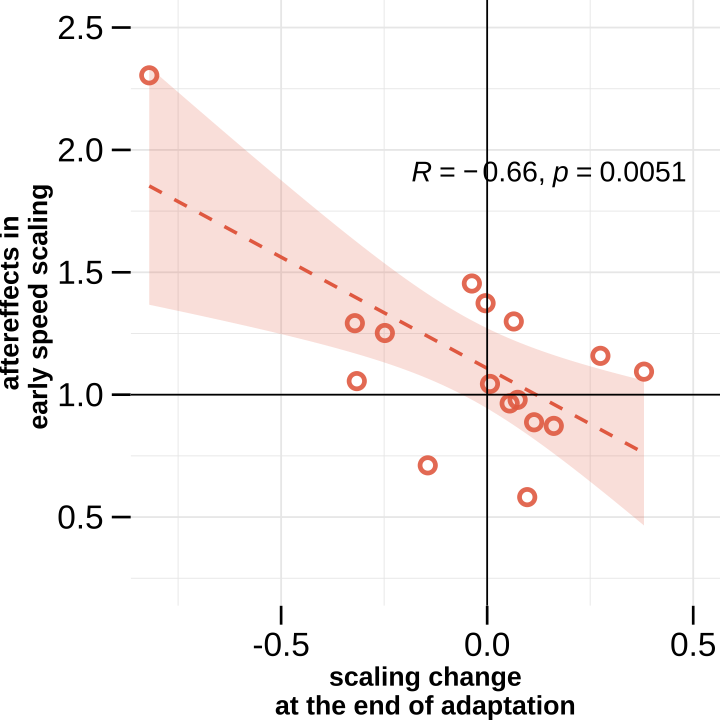

In [48]:
options(repr.plot.width=6, repr.plot.height=6)
ggplot(aes(y = slopesR2_corr_mn_start.washout, x = onCompR_corr_mn_end.plateau),
        data = summDat2_wide %>% filter(grp=="adults" & tgtHtC=="wide" & gHand=="r-only")) + 

    coord_capped_cart(ylim = c(0.25, 2.5), xlim = c(-0.8, 0.5)) + 
    
    geom_point(show.legend = FALSE,col="#e76f51", shape = 1, size = 3, alpha = 0.9, stroke=2) + 
    geom_smooth(aes(group = 1), formula = y~x, col = "#e76f51", fill = "#e76f51", lty = "dashed", alpha = 0.2, method = "lm",show.legend = FALSE) +
    
    geom_hline(yintercept = 1, color = "black", size = 0.5) +
    geom_vline(xintercept = 0, color = "black", size = 0.5) +
    
    stat_cor(size = 6, label.x.npc = 0.53, label.y = 1.9, method = "pearson", nboot = 1000, show.legend = FALSE) +
    
    labs(x = "scaling change\nat the end of adaptation", y = "aftereffects in\nearly speed scaling ") +
    theme_minimal() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0), "inches"),
          plot.background = element_blank(),
          axis.line = element_blank(), panel.border = element_blank())

### S4: greater right-hand compensation was associated with greater left-hand compensation in both right-only vs bilateral perturbation groups

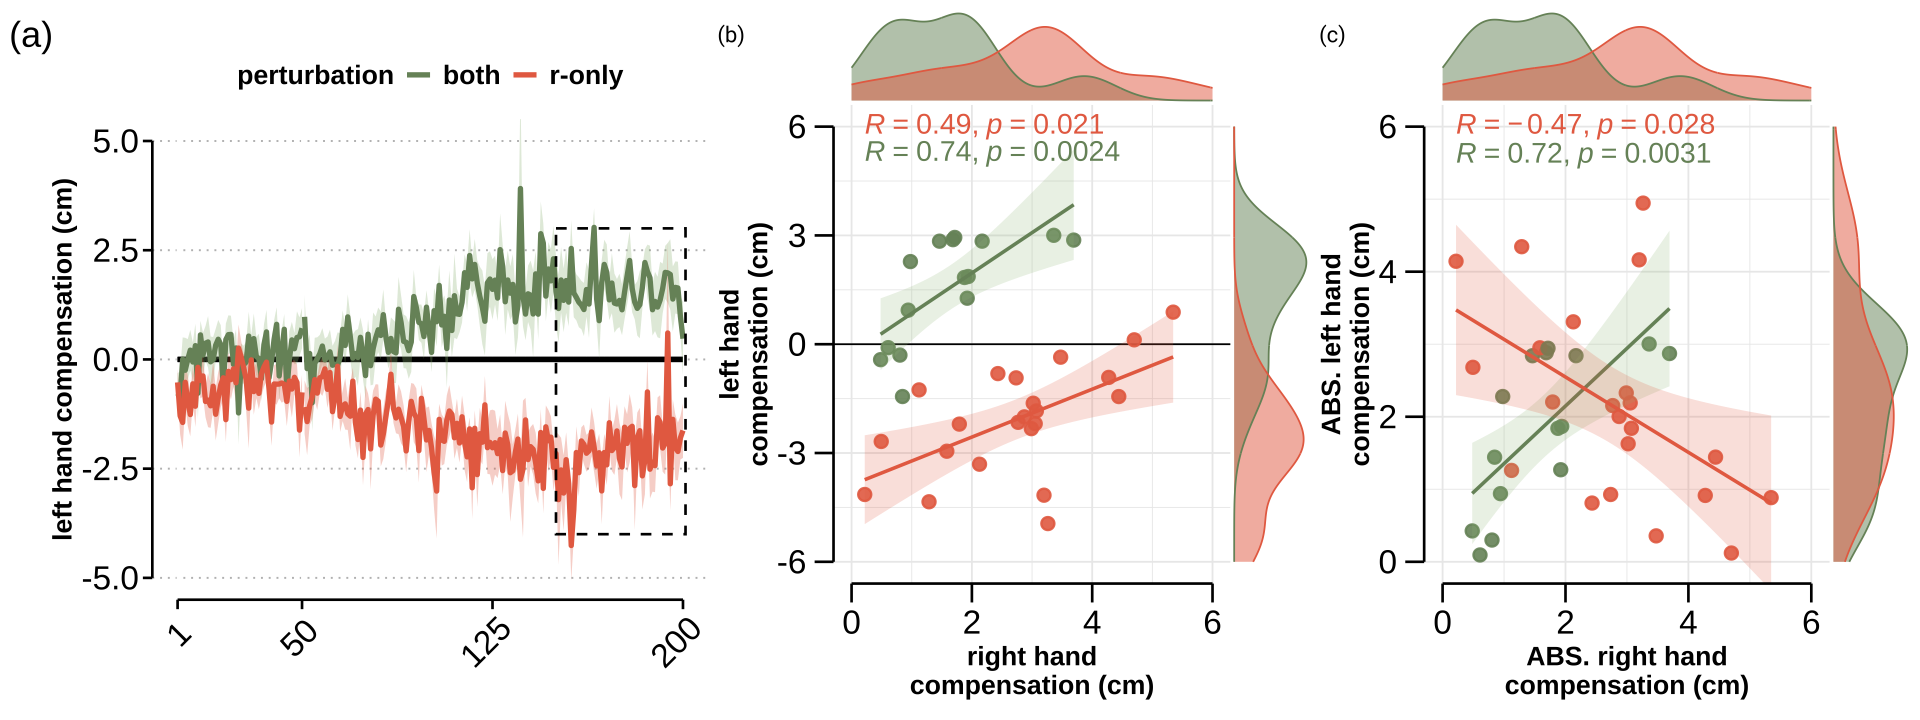

In [49]:
#-------------------------------------misc-plots---------------------------------

FigS4a = ggplot(aes(x = trial, y = tilt_compL_raw*100, group = interaction(gHand, cond), col = gHand, fill = gHand),
        data = dat3 %>% filter(grp == "adults" & tgtHtC == "narrow" & expGrp=="bimanual" & cond != "washout")) +     
    
    coord_capped_cart(ylim = c(-5,5), xlim = c(1, 200), bottom = 'both', left = 'both') +
 
    geom_line(aes(y = 0), col = "black", size = 1.5) +

    stat_summary_bin(geom = "ribbon", fun.data = mean_se, binwidth = 1, lwd = NA, alpha = 0.3, show.legend = FALSE) +
    stat_summary_bin(geom = "line", fun.y = mean, binwidth = 1, lwd = 1.5, alpha = 1, show.legend = TRUE) +
    
    annotate("rect", xmin = 150, xmax = 201, ymin = -4, ymax = 3, fill = NA, 
            color = "black", linetype = "dashed", linewidth = 0.75) +

    scale_color_manual(name = "perturbation", values = c("r-only" = "#e76f51", "both" = "#779269ff")) +
    scale_fill_manual(name = "perturbation", values = c("r-only" = "#e76f51", "both" = "#9cbd88ff")) +
    scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
    labs(y = "left hand compensation (cm)", x = "") +

    theme_pubclean() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0), "inches"), #c(top, right, bottom, left)
          plot.background = element_blank(),
          panel.border = element_blank(),
          panel.spacing = unit(2, "lines"),
          axis.ticks.length = unit(0.2, "cm"),
          legend.position = "top",
          axis.line.y = element_line(colour = "black"),
          axis.text.x = element_text(angle = 45, vjust = 0.8, hjust = 0.8),
          strip.background = element_blank(),
          plot.title = element_text(hjust = 0.5, size = 14, face = "bold"))

FigS4b = ggplot(aes(x = (tilt_compR_raw_mn)*100, y = (tilt_compL_raw_mn)*100, col = gHand, fill = gHand),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="end.plateau" & expGrp=="bimanual" & 
                                   gHand %in% c("r-only", "both"))) + 

    coord_capped_cart(xlim = c(0, 6), ylim = c(-6, 6), left = "both", bottom = "both") +
    geom_hline(yintercept = 0, color = "black", size = 0.5) +

    geom_point(show.legend = FALSE, size = 3, alpha = 0.9, stroke=1) + 
    geom_smooth(aes(group = gHand), formula = y~x, alpha = 0.2, method = "lm", se = TRUE, show.legend = FALSE) +

    stat_cor(method = "spearman", show.legend = FALSE, size = 6, label.y = c(5.25, 6)) +

    scale_color_manual(values = c("r-only" = "#e76f51", "both" = "#779269ff")) +
    scale_fill_manual(values = c("r-only" = "#e76f51", "both" = "#9cbd88ff")) +
    
    labs(x = "right hand\ncompensation (cm)", y = "left hand\ncompensation (cm)") +
    theme_minimal() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0), "inches"),
          plot.background = element_blank(),
          panel.border = element_blank(),
          legend.position = "top",
          plot.title = element_text(hjust = 0.5, size = 14, face = "bold"))

FigS4c = ggplot(aes(x = abs(tilt_compR_raw_mn)*100, y = abs(tilt_compL_raw_mn)*100, col = gHand, fill = gHand),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="end.plateau" & expGrp=="bimanual" & 
                                   gHand %in% c("r-only", "both"))) + 

    coord_capped_cart(xlim = c(0, 6), ylim = c(0, 6), left = "both", bottom = "both") +

    geom_point(show.legend = FALSE, size = 3, alpha = 0.9, stroke=1) + 
    geom_smooth(aes(group = gHand), formula = y~x, alpha = 0.2, method = "lm", se = TRUE, show.legend = FALSE) +

    stat_cor(method = "spearman", show.legend = FALSE, size = 6, label.y = c(5.6, 6)) +

    scale_color_manual(values = c("r-only" = "#e76f51", "both" = "#779269ff")) +
    scale_fill_manual(values = c("r-only" = "#e76f51", "both" = "#9cbd88ff")) +
    
    labs(x = "ABS. right hand\ncompensation (cm)", y = "ABS. left hand\ncompensation (cm)") +
    theme_minimal() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0), "inches"),
          plot.background = element_blank(),
          panel.border = element_blank(),
          legend.position = "top",
          plot.title = element_text(hjust = 0.5, size = 14, face = "bold"))


FigS4b_marg = ggMarginal(FigS4b, groupColour = TRUE, groupFill = TRUE, type = "density",adjust = 1)
FigS4c_marg = ggMarginal(FigS4c, groupColour = TRUE, groupFill = TRUE, type = "density",adjust = 1)

options(repr.plot.width=16, repr.plot.height=6)
FigS4a + FigS4b_marg + FigS4c_marg + plot_layout(ncol = 3, nrow = 1) + 
plot_annotation(tag_levels = 'a', tag_prefix = '(', tag_suffix = ')')

### S5: left- and right-hand displacement aftereffects in the bilateral-gain group compared to right-only gain group

In [53]:
FigS5a = ggplot(aes(x = trial, y = (Ry_raw)*100, group = interaction(expGrp, gHand), 
                   col = interaction(expGrp, gHand), fill = interaction(expGrp, gHand)),
             data = dat3 %>% filter(grp=="adults", tgtHtC=="narrow", cond=="washout", 
                                   (gHand=="both" | gHand=="r-only"))) +
    coord_capped_cart(ylim = c(28,40), xlim = c(201, 260), bottom = 'both', left = 'both') +
    stat_summary_bin(geom="ribbon", fun.data = mean_se, binwidth=1, lwd=NA, alpha=0.5, show.legend = FALSE) +
    stat_summary_bin(geom="line", fun.y = mean, binwidth=1, lwd=1.5, alpha=0.9, show.legend = FALSE) +
    
    geom_vline(xintercept = c(211,241), lty = "dashed", col = "gray") +

    scale_x_continuous(breaks = c(1,50,125,200, 260), labels = c("1","50","125","200","260")) +
    
    scale_color_manual(values = c("unimanual.r-only" = "#264653", 
                                 "bimanual.r-only" = "#e76f51",
                                 "bimanual.both" = "#779269ff")) +
    scale_fill_manual(values = c("unimanual.r-only" = "#458999", 
                                "bimanual.r-only" = "#fbad93ff",
                                "bimanual.both" = "#9cbd88ff")) +
    
    annotate("rect", xmin = 200, xmax = 206, ymin = 28, ymax = 37, fill = NA, 
           color = "#404040e3", linetype = "dashed", linewidth = 0.75) +

    labs(x = "", y = "right hand displacement (cm)") +
    theme_clean() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0),"inches"),
      plot.background = element_blank(),
      panel.border = element_blank(),
      panel.spacing = unit(2, "lines"),
      axis.ticks.length=unit(0.2,"cm"),
      legend.position="top",
      axis.line.y = element_line(colour = "black"),
      axis.text.x = element_text(angle = 45, vjust = 0.8, hjust=0.8),
      strip.background = element_blank())


FigS5a_inset = ggplot(aes(x = factor(interaction(expGrp, gHand), 
                                   levels = c("unimanual.r-only", "bimanual.r-only", "bimanual.both")), 
                         y = Ry_raw_mn*100, 
                         col = interaction(expGrp, gHand), fill = interaction(expGrp, gHand)),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="start.washout" & 
                                   (gHand=="both" | gHand=="r-only"))) +

    geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    coord_capped_cart(ylim = c(25,40),bottom = "both",left = "both") +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
    
    scale_x_discrete(labels = c("unimanual.r-only" = "uni\nright", 
                               "bimanual.r-only" = "bi\nright", 
                               "bimanual.both" = "bi\nboth")) +
    
    scale_color_manual(values = c("unimanual.r-only" = "#264653", 
                                 "bimanual.r-only" = "#e76f51",
                                 "bimanual.both" = "#779269ff")) +
    scale_fill_manual(values = c("unimanual.r-only" = "#264653", 
                                "bimanual.r-only" = "#e76f51",
                                "bimanual.both" = "#779269ff")) +
    
    labs(x = "", y = "") + # plate displacement (cm) removed label
    theme_pubclean() + thm

FigS5a_withInset <- FigS5a + 
  inset_element(FigS5a_inset, left = 0.45, bottom = 0.4, right = 0.95, top = 1.0)+
   theme(plot.background = element_rect(fill = "white", color = "black", linetype = "dashed", size = 0.75))
   

In [54]:
FigS5b = ggplot(aes(x = trial, y = (Ly_raw)*100, group = interaction(expGrp, gHand), 
                   col = interaction(expGrp, gHand), fill = interaction(expGrp, gHand)),
             data = dat3 %>% filter(grp=="adults", tgtHtC=="narrow", cond=="washout", expGrp!="unimanual", 
                                   (gHand=="both" | gHand=="r-only"))) +
    coord_capped_cart(ylim = c(28,40), xlim = c(201, 260), bottom = 'both', left = 'both') +
    stat_summary_bin(geom="ribbon", fun.data = mean_se, binwidth=1, lwd=NA, alpha=0.5, show.legend = FALSE) +
    stat_summary_bin(geom="line", fun.y = mean, binwidth=1, lwd=1.5, alpha=0.9, show.legend = FALSE) +
    
    geom_vline(xintercept = c(211,241), lty = "dashed", col = "gray") +

    scale_x_continuous(breaks = c(1,50,125,200, 260), labels = c("1","50","125","200","260")) +
    
    scale_color_manual(values = c("unimanual.r-only" = "#264653", 
                                 "bimanual.r-only" = "#e76f51",
                                 "bimanual.both" = "#779269ff")) +
    scale_fill_manual(values = c("unimanual.r-only" = "#458999", 
                                "bimanual.r-only" = "#fbad93ff",
                                "bimanual.both" = "#9cbd88ff")) +
    
    annotate("rect", xmin = 200, xmax = 206, ymin = 28, ymax = 37, fill = NA, 
           color = "#404040e3", linetype = "dashed", linewidth = 0.75) +

    labs(x = "", y = "left hand displacement (cm)") +
    theme_clean() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0),"inches"),
      plot.background = element_blank(),
      panel.border = element_blank(),
      panel.spacing = unit(2, "lines"),
      axis.ticks.length=unit(0.2,"cm"),
      legend.position="top",
      axis.line.y = element_line(colour = "black"),
      axis.text.x = element_text(angle = 45, vjust = 0.8, hjust=0.8),
      strip.background = element_blank())


FigS5b_inset = ggplot(aes(x = factor(interaction(expGrp, gHand), 
                                   levels = c("unimanual.r-only", "bimanual.r-only", "bimanual.both")), 
                         y = Ly_raw_mn*100, 
                         col = interaction(expGrp, gHand), fill = interaction(expGrp, gHand)),
        data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow" & cond3=="start.washout" & expGrp!="unimanual" &
                                   (gHand=="both" | gHand=="r-only"))) +

    geom_point(position = position_jitterdodge(jitter.width = 0.3, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), size = 1.2, show.legend = FALSE, alpha = 0.7) +
    coord_capped_cart(ylim = c(25,40),bottom = "both",left = "both") +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, linewidth = 1.25, show.legend = FALSE) +
    
    scale_x_discrete(labels = c("unimanual.r-only" = "uni", 
                               "bimanual.r-only" = "bi\nright", 
                               "bimanual.both" = "bi\nboth")) +
    
    scale_color_manual(values = c("unimanual.r-only" = "#264653", 
                                 "bimanual.r-only" = "#e76f51",
                                 "bimanual.both" = "#779269ff")) +
    scale_fill_manual(values = c("unimanual.r-only" = "#264653", 
                                "bimanual.r-only" = "#e76f51",
                                "bimanual.both" = "#779269ff")) +
    
    labs(x = "", y = "") + # plate displacement (cm) removed label
    theme_pubclean() + thm

FigS5b_withInset <- FigS5b + 
  inset_element(FigS5b_inset, left = 0.45, bottom = 0.4, right = 0.95, top = 1.0)+
   theme(plot.background = element_rect(fill = "white", color = "black", linetype = "dashed", size = 0.75))

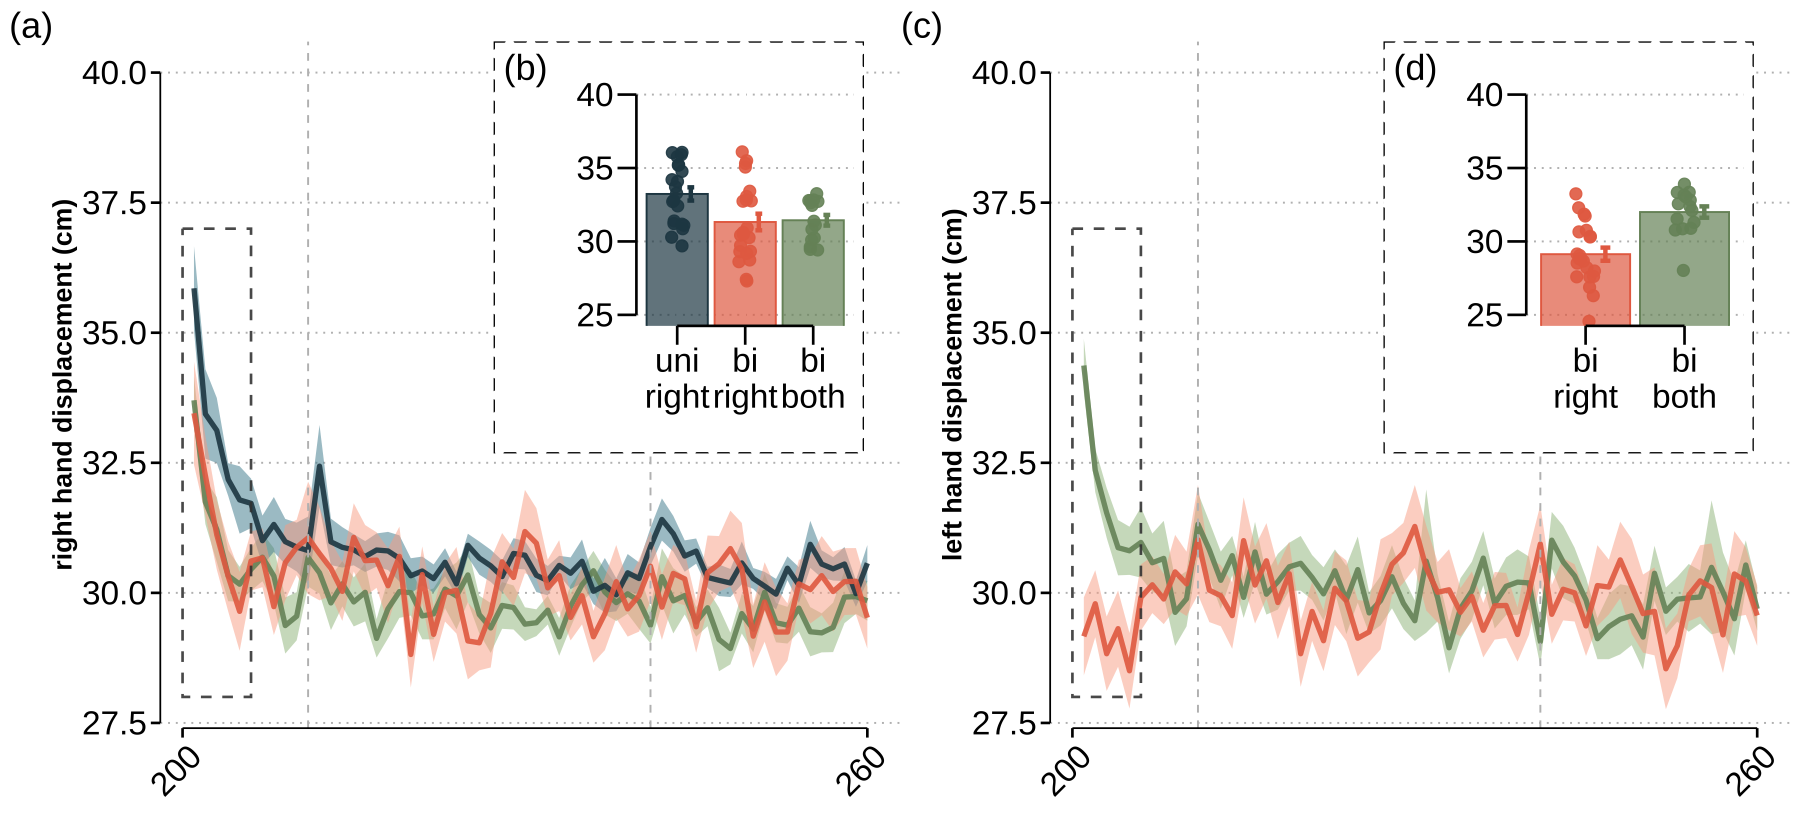

In [56]:
options(repr.plot.width=15, repr.plot.height=7)
FigS5 = FigS5a_withInset + FigS5b_withInset + plot_layout(ncol = 2, nrow = 1) + 
plot_annotation(tag_levels = 'a', tag_prefix = '(', tag_suffix = ')')
FigS5

### S6: compensatory hand adjustments (tilt compensation) showed aftereffects in all three bimanual groups

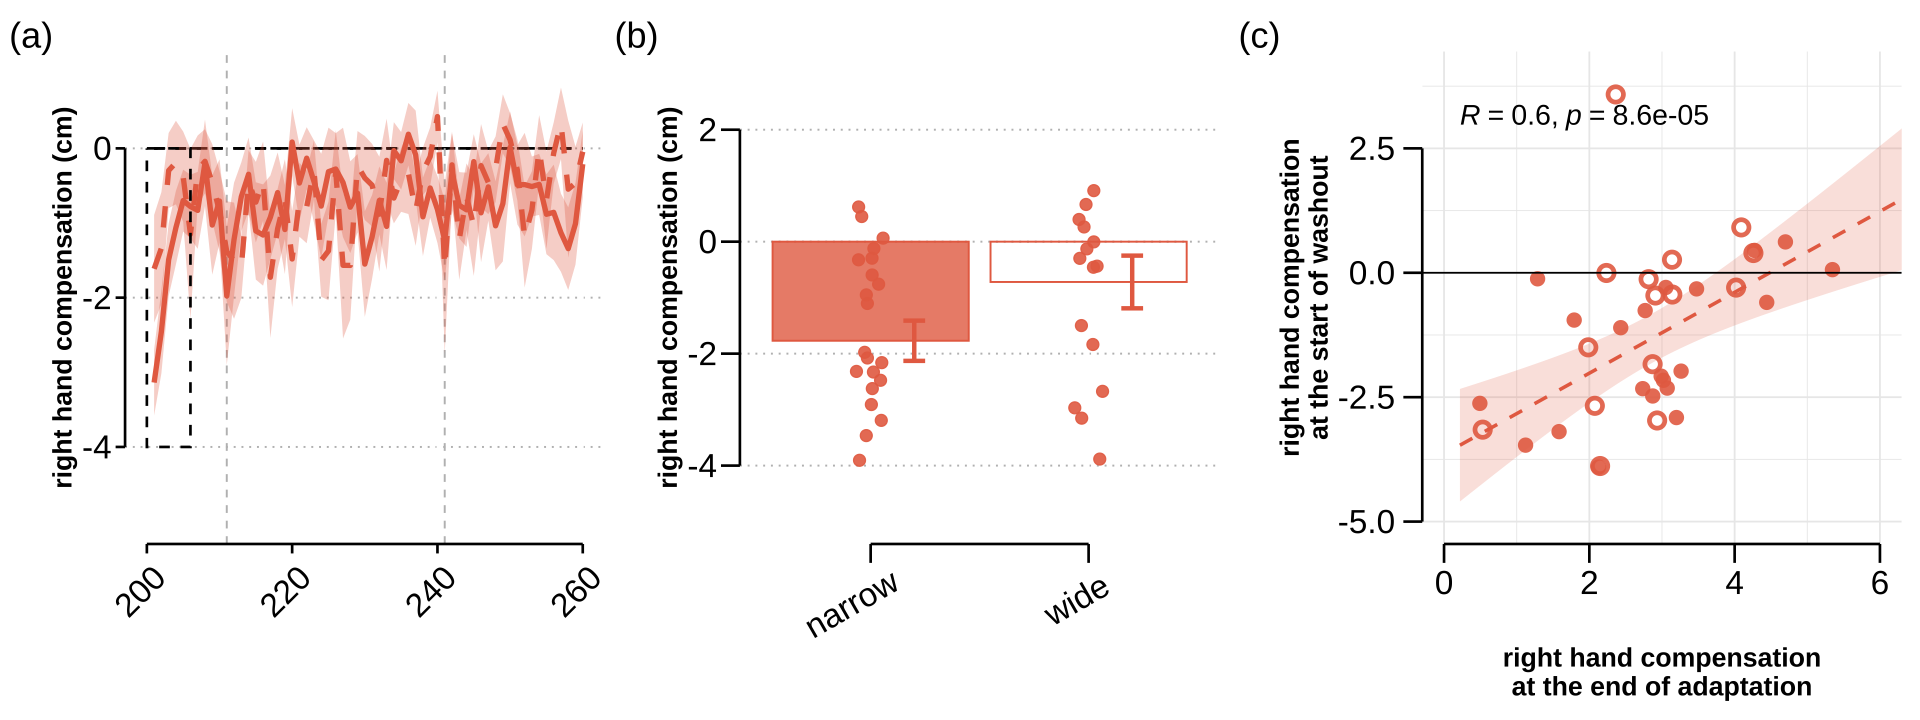

In [51]:
FigS6a = ggplot(aes(x = trial, y = tilt_compR_raw*100, group = interaction(tgtHtC, cond), lty = tgtHtC),
        data = dat3 %>% filter(grp == "adults" & expGrp=="bimanual" & gHand=="r-only" & cond=="washout")) +     
    
    coord_capped_cart(ylim = c(-5,1), xlim = c(200, 260), bottom = 'both', left = 'both') +
 
    geom_line(aes(y = 0), col = "black", size = 0.75, lty="dashed") +
    geom_vline(xintercept = c(211,241),lty = "dashed", col = "gray") +

    stat_summary_bin(geom = "ribbon", fun.data = mean_se, binwidth = 1, fill = "#e76f51", lwd = NA, alpha = 0.3, show.legend = FALSE) +
    stat_summary_bin(geom = "line", fun.y = mean, binwidth = 1, lwd = 1.5, col="#e76f51", alpha = 1, show.legend = FALSE) +
    
    annotate("rect", xmin = 200, xmax = 206, ymin = -4, ymax = 0, fill = NA, 
            color = "black", linetype = "dashed", linewidth = 0.75) +
    scale_linetype_manual(values = c("solid","dashed")) +
    labs(y = "right hand compensation (cm)", x = "") +

    theme_pubclean() + thm +
    theme(plot.margin = unit(c(0, 0, 0, 0), "inches"), #c(top, right, bottom, left)
          plot.background = element_blank(),
          panel.border = element_blank(),
          panel.spacing = unit(2, "lines"),
          axis.ticks.length = unit(0.2, "cm"),
          legend.position = "top",
          axis.line.y = element_line(colour = "black"),
          axis.text.x = element_text(angle = 45, vjust = 0.8, hjust = 0.8),
          strip.background = element_blank(),
          plot.title = element_text(hjust = 0.5, size = 14, face = "bold"))

FigS6b = ggplot(aes(x = tgtHtC, y = tilt_compR_raw_mn*100, group = tgtHtC, col = tgtHtC, fill = tgtHtC),
        data = summDat2 %>% filter(grp=="adults" & gHand=="r-only" & expGrp=="bimanual" & cond3=="start.washout")) +
    coord_capped_cart(ylim = c(-5,3),bottom = "both",left = "both") +
    
    stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.1), stroke = 1.5, 
                 size = 1.2, show.legend = FALSE, alpha = 0.8) +
    stat_summary(fun.data = mean_se, geom = "errorbar",position = position_nudge(x = 0.2), width = 0.1, 
                 linewidth = 1.25, show.legend = FALSE) +
    geom_point(position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.5), alpha = 0.9, size = 3, show.legend =FALSE) +
    
    scale_color_manual(values = c("narrow" = "#e76f51", "wide" = "#e76f51")) +
    scale_fill_manual(values = c("narrow" = "#e76f51", "wide" = NA)) +
  
    labs(y = "right hand compensation (cm)", x = "") +
    
    theme_pubclean() + thm  + 
    theme(axis.text.x = element_text(angle = 30, vjust = 0.75, hjust = 0.75))

FigS6c = ggplot(aes(y = (tilt_compR_raw_mn_start.washout)*100, x = tilt_compR_raw_mn_end.plateau*100, group = tgtHtC, shape = tgtHtC),
        data = summDat2_wide %>% filter(grp == "adults" & expGrp=="bimanual" & gHand=="r-only")) + 

    coord_capped_cart(ylim = c(-5, 4), xlim = c(0, 6),left = "both",bottom="both") + 
    
    geom_point(show.legend = FALSE,col="#e76f51", size = 3, alpha = 0.9, stroke=2) + 
    geom_smooth(aes(group = 1), formula = y~x, col = "#e76f51", fill = "#e76f51", lty = "dashed", alpha = 0.2, method = "lm",show.legend = FALSE) +
    
    geom_hline(yintercept = 0, color = "black", size = 0.5) +
    scale_shape_manual(values = c(16,1)) +
    stat_cor(aes(group = 1), size = 6, method = "spearman", nboot = 1000, show.legend = FALSE) +
    
    labs(x = "right hand compensation\nat the end of adaptation", y = "right hand compensation\nat the start of washout") +
    theme_minimal() + thm

FigS6a + FigS6b + FigS6c + plot_layout(ncol = 3, nrow = 1) + 
plot_annotation(tag_levels = 'a', tag_prefix = '(', tag_suffix = ')')

## Misc

In [ ]:
# define expected trials per epoch
expected_per_epoch <- tibble(
  cond3 = c("baseline", "start.ramp", "end.ramp", "start.plateau", "end.plateau", "start.washout", "end.washout"),
  expected = c(10, 25, 25, 25, 50, 5, 10)
)

# calculate missingness per participant per epoch
missing_by_epoch <- summDat %>%
  filter(grp == "adults") %>%
  group_by(subj, cond3) %>%
  summarise(n_trials = n(), .groups = "drop") %>%
  left_join(expected_per_epoch, by = "cond3") %>%
  mutate(missing = expected - n_trials)

# summarize per epoch
epoch_summary <- missing_by_epoch %>%
  group_by(cond3) %>%
  summarise(mean_missing = mean(missing),
            sd_missing = sd(missing),
            min_missing = min(missing),
            max_missing = max(missing))

print(epoch_summary)

# overall missingness (for reporting)
overall_missing <- missing_by_epoch %>%
  group_by(subj) %>%
  summarise(total_missing = sum(missing)) %>%
  ungroup()

mean_missing <- mean(overall_missing$total_missing)
sd_missing <- sd(overall_missing$total_missing)
min_missing <- min(overall_missing$total_missing)
max_missing <- max(overall_missing$total_missing)

cat(sprintf("Missing trials were removed from analysis; on average, %.1f ± %.1f trials were excluded per participant (range: %d–%d).",
            mean_missing, sd_missing, min_missing, max_missing))

# A tibble: 7 × 5
  cond3         mean_missing sd_missing min_missing max_missing
  <chr>                <dbl>      <dbl>       <dbl>       <dbl>
1 baseline             0.189      0.515           0           3
2 end.plateau        -20.2        3.32          -25          -9
3 end.ramp             2.46       2.09            0           9
4 end.washout         -0.635      0.632          -1           2
5 start.plateau        2.88       2.23            0           9
6 start.ramp           0.932      1.44            0           6
7 start.washout        0.230      0.511           0           2
Missing trials were removed from analysis; on average, -14.1 ± 7.3 trials were excluded per participant (range: -26–4).

In [ ]:
packageVersion("MASS")
packageVersion("robustlmm")
packageVersion("emmeans")
packageVersion("ggplot2")

[1] ‘7.3.65’

[1] ‘3.3.3’

[1] ‘1.11.2.8’

[1] ‘4.0.0’

In [ ]:
sessionInfo()

R version 4.5.1 (2025-06-13)
Platform: x86_64-apple-darwin20
Running under: macOS Sequoia 15.7.2

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.5-x86_64/Resources/lib/libRblas.0.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.5-x86_64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] en_US/en_US/en_US/C/en_US/en_US

time zone: America/New_York
tzcode source: internal

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] robustlmm_3.3-3    MASS_7.3-65        broom_1.0.10       showtextdb_3.0    
 [5] sysfonts_0.8.9     car_3.1-3          carData_3.0-5      emmeans_1.11.2-8  
 [9] viridis_0.6.5      viridisLite_0.4.2  svglite_2.2.1      lemon_0.5.2       
[13] ggthemes_5.1.0     ggExtra_0.11.0     plotly_4.11.0      lme4_1.1-37       
[17] Matrix_1.7-3       sjPlot_2.9.0       sjstats_0.19.1     performance_0.15.2
[21] see_0.12.0         scat

## The End